# Data Pipeline — v7

This notebook implements the complete data-processing pipeline for
*Endogenous Education Choice in Segmented Search Markets*.

**Changes from v6 (implementing `data_and_moments.pdf` Part VII):**

| # | Change | Section |
|---|--------|---------|
| 1 | Drop `exp_ur_total`, `exp_ur_U`, `exp_ur_S` (collinear with level rates) | Helpers / Stage 7 / 8 |
| 2 | Add `train_entry_rate_U`: monthly hazard U-unemp → enrolled | Stage 4 / 7 / 8 |
| 3 | Apply `LF ∩ ¬train` filter to denominators of `ur_total`, `ur_U`, `skilled_share` | Stage 7 stocks |
| 4 | `training_share` switched to strict variant (NILF trainees / working-age population) | Stage 7 stocks |
| 5 | `ee_rate_S`: E4-only is the production method (no fallback) | Stage 5 |
| 6 | Pre-estimate ν on **both** `base_fc` and `base_covid`; renamed `nu_estimate.csv` → `nu_estimation.csv` | Stage 6 |
| 7 | `MOMENT_NAMES` → 24 entries; Σ̂ matrices are 24 × 24 | Helpers / Stage 8 |
| 8 | Persist `WINDOWS` to `derived/windows.json` — single source of truth shared with the descriptive notebook | Stage 0 |
| 9 | New diagnostics: stationary-identity gap by window; `train_entry_rate_U` cross-window comparison | Stage 9 |

**Convention.** Skilled iff `EDUC ≥ 111`. Training iff `SCHLCOLL ∈ {3,4}` and `EDUC < 111`.
Model labour force `model_lf = agg_uU + agg_eU + agg_mS` excludes the training mass `agg_t`,
which is why all stock denominators apply the `LF ∩ ¬train` filter.

**Single place to edit windows.** All four estimation windows are defined exactly once,
in the `WINDOWS` const at Stage 0. They are also written to `data/derived/windows.json`
so the descriptive analysis notebook can read them without redefinition.


## Setup

Load all required packages.

In [1]:
using DataFrames
using CSV
using Arrow
using Statistics
using Printf
using HTTP, JSON3
using XLSX          # for reading NSC Excel file
using LinearAlgebra # for influence function / Σ computation


### Paths

Adjust `PROJECT_ROOT` if your notebook lives somewhere other than `code/notebooks/`.

In [2]:
# ── Paths ──────────────────────────────────────────────────────
const PROJECT_ROOT      = joinpath(@__DIR__, "..", "..")
const DATA_DIR          = joinpath(PROJECT_ROOT, "data")
const RAW_DIR           = joinpath(DATA_DIR, "raw")
const DERIVED_DIR       = joinpath(DATA_DIR, "derived")

const RAW_CPS_BASIC_DIR = joinpath(RAW_DIR, "cps_basic")
const RAW_CPS_ASEC_DIR  = joinpath(RAW_DIR, "cps_asec")
const RAW_JOLTS_DIR     = joinpath(RAW_DIR, "jolts")
const RAW_J2J_DIR       = joinpath(RAW_DIR, "j2j")
const RAW_NSC_DIR       = joinpath(RAW_DIR, "nsc")

mkpath(DERIVED_DIR)

println("PROJECT_ROOT = ", PROJECT_ROOT)
println("DERIVED_DIR  = ", DERIVED_DIR)

PROJECT_ROOT = /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../..
DERIVED_DIR  = /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived


### Estimation Windows & Helper Functions

All shared utilities. Key changes from original:
- Vectorised `ym`-based window filter
- SCHLCOLL fix: `(3, 4)` not `(4, 5)`
- COVID correction using WHYABSNT
- Corrected IND-to-JOLTS mapping (verified against 2024 ACS Code Lists)
- Renamed `winsorize_bounds` → `trim_bounds`

In [3]:
# ============================================================
# Estimation windows — vectorised ym-based filter
# ----------------------------------------------------------
# THIS IS THE SINGLE SOURCE OF TRUTH for the four windows.
# Any other notebook (e.g. descriptive_analysis) should read
# them from `derived/windows.json`, written below.
# ============================================================

const WINDOWS = Dict{Symbol, NamedTuple}(
    :base_fc      => (label = "Pre-FC baseline",
                      ym_start = 200301, ym_end = 200712,
                      asec_years = 2004:2008),
    :crisis_fc    => (label = "Financial crisis",
                      ym_start = 200801, ym_end = 201012,
                      asec_years = 2009:2011),
    :base_covid   => (label = "Pre-COVID baseline",
                      ym_start = 201501, ym_end = 201912,
                      asec_years = 2016:2020),
    :crisis_covid => (label = "COVID crisis",
                      ym_start = 202001, ym_end = 202212,
                      asec_years = 2021:2023),
)

const WINDOWS_ORDER = [:base_fc, :crisis_fc, :base_covid, :crisis_covid]

# Integer ym = 100*year + month for fast comparison
ym_int(year::Int, month::Int)::Int = 100 * year + month

function assign_window(year::Int, month::Int)::Symbol
    ym = ym_int(year, month)
    for (wname, wdef) in WINDOWS
        (wdef.ym_start <= ym <= wdef.ym_end) && return wname
    end
    return :none
end

function assign_asec_window(survey_year::Int)::Symbol
    for (wname, wdef) in WINDOWS
        (survey_year in wdef.asec_years) && return wname
    end
    return :none
end

# ── Persist WINDOWS for sister notebooks ─────────────────────────
# `derived/windows.json` is the canonical record used by
# descriptive_analysis and any downstream consumer. Re-written
# every time this cell runs so the file never goes stale.
function _windows_to_dict()
    out = Dict{String, Any}()
    for (k, v) in WINDOWS
        out[String(k)] = Dict(
            "label"      => v.label,
            "ym_start"   => v.ym_start,
            "ym_end"     => v.ym_end,
            "asec_years" => collect(v.asec_years),
        )
    end
    return Dict(
        "windows"       => out,
        "windows_order" => String.(WINDOWS_ORDER),
    )
end

let
    mkpath(DERIVED_DIR)
    open(joinpath(DERIVED_DIR, "windows.json"), "w") do io
        JSON3.pretty(io, _windows_to_dict())
    end
    @info "  Wrote derived/windows.json"
end

# ============================================================
# Classification helpers
# ============================================================

is_skilled(educ::Integer)::Bool = educ >= 111
in_age_range(age::Integer; lo::Int=16, hi::Int=64)::Bool = lo <= age <= hi
is_civilian_lf(labforce::Integer)::Bool = labforce == 2
is_employed(empstat::Integer)::Bool = empstat in (10, 12)
is_unemployed(empstat::Integer)::Bool = empstat in (20, 21, 22)
is_nilf(empstat::Integer)::Bool = empstat in (30, 31, 32, 33, 34, 36)
is_wage_worker(classwkr::Integer)::Bool = classwkr in (22, 25, 27, 28)

# FIX (v6): was (4, 5) — code 5 = "does not attend school", code 3 = "college full-time"
is_enrolled_no_ba(schlcoll::Integer, educ::Integer)::Bool = schlcoll in (3, 4) && educ < 111

valid_match_mish(mish::Integer)::Bool = mish in (1, 2, 3, 5, 6, 7)

# ============================================================
# COVID BLS misclassification correction
# ============================================================

function apply_covid_correction(empstat::Integer, year::Int, month::Int,
                                whyabsnt::Integer)::Integer
    (year == 2020 && 3 <= month <= 6) || return empstat
    if is_employed(empstat) && whyabsnt == 15
        return 21  # unemployed, temporary layoff
    end
    return empstat
end

# ============================================================
# Wage construction
# ============================================================

function compute_hourly_wage(incwage, wkswork1, uhrsworkly)::Float64
    (wkswork1 <= 0 || uhrsworkly <= 0 || incwage <= 0) && return NaN
    return Float64(incwage) / (Float64(wkswork1) * Float64(uhrsworkly))
end

deflate_wage(nominal_wage::Float64, cpi_t::Float64, cpi_base::Float64)::Float64 =
    nominal_wage * (cpi_base / cpi_t)

# ============================================================
# Trimming (renamed from winsorize_bounds)
# ============================================================

function trim_bounds(wages::AbstractVector{Float64}, weights::AbstractVector{Float64};
                     lo_pct::Float64=0.01, hi_pct::Float64=0.99)
    n = length(wages)
    n == 0 && return (NaN, NaN)
    idx = sortperm(wages)
    cum = 0.0
    total = sum(weights)
    total <= 0.0 && return (NaN, NaN)
    lo_val = wages[idx[1]]
    hi_val = wages[idx[end]]
    for i in idx
        cum += weights[i] / total
        if cum >= lo_pct && lo_val == wages[idx[1]]
            lo_val = wages[i]
        end
        if cum >= hi_pct
            hi_val = wages[i]
            break
        end
    end
    return (lo_val, hi_val)
end

# ============================================================
# Weighted statistics
# ============================================================

function wmean(x::AbstractVector, w::AbstractVector)::Float64
    sw = sum(w); sw <= 0.0 && return NaN
    return sum(x .* w) / sw
end

function wmedian(x::AbstractVector, w::AbstractVector)::Float64
    n = length(x); n == 0 && return NaN
    idx = sortperm(x)
    cum = 0.0; total = sum(w)
    total <= 0.0 && return NaN
    for i in idx
        cum += w[i] / total
        cum >= 0.5 && return Float64(x[i])
    end
    return Float64(x[idx[end]])
end

function wpercentile25(x::AbstractVector, w::AbstractVector)::Float64
    n = length(x); n == 0 && return NaN
    ord = sortperm(x)
    xs, ws = x[ord], w[ord]
    cs = cumsum(ws)
    total = cs[end]
    total <= 0.0 && return NaN
    target = 0.25 * total
    i = searchsortedfirst(cs, target)
    i = clamp(i, 1, length(xs))
    return Float64(xs[i])
end


function wvar(x::AbstractVector, w::AbstractVector)::Float64
    m = wmean(x, w); sw = sum(w)
    sw <= 0.0 && return NaN
    return sum(w .* (x .- m).^2) / sw
end

wsd(x::AbstractVector, w::AbstractVector)::Float64 = sqrt(max(wvar(x, w), 0.0))

function wcm3(x::AbstractVector, w::AbstractVector)::Float64
    m = wmean(x, w); sw = sum(w)
    sw <= 0.0 && return NaN
    return sum(w .* (x .- m).^3) / sw
end

# Kernel density at a point (for influence function of weighted median)
function kde_at_point(x::AbstractVector, w::AbstractVector, point::Float64;
                      bw::Float64=NaN)::Float64
    n = length(x)
    n == 0 && return NaN
    if isnan(bw)
        s = wsd(x, w)
        n_eff = sum(w)^2 / sum(w.^2)
        bw = 1.06 * s * n_eff^(-0.2)
    end
    bw <= 0.0 && return NaN
    sw = sum(w)
    density = 0.0
    for i in 1:n
        u = (x[i] - point) / bw
        density += w[i] * exp(-0.5 * u^2) / sqrt(2π)
    end
    return density / (sw * bw)
end

# ============================================================
# IND-to-JOLTS supersector mapping (verified against 2024 ACS)
# ============================================================

function ind_to_jolts_supersector(ind::Int)::String
    ind == 270               && return "100000"  # Logging → Mining & Logging
    170 <= ind <= 290        && return "EXCLUDED" # Agriculture (excl. logging)
    370 <= ind <= 490        && return "100000"  # Mining
    570 <= ind <= 690        && return "480099"  # Utilities → TWU
    ind == 770               && return "230000"  # Construction
    1070 <= ind <= 1990      && return "340000"  # Nondurable mfg (Food–Printing)
    2070 <= ind <= 2390      && return "340000"  # Nondurable mfg (Petrol/Chem/Plastics)
    2470 <= ind <= 3990      && return "320000"  # Durable mfg
    4070 <= ind <= 4590      && return "420000"  # Wholesale
    4670 <= ind <= 5791      && return "440000"  # Retail
    6070 <= ind <= 6390      && return "480099"  # Transport/Warehousing → TWU
    6471 <= ind <= 6781      && return "510000"  # Information
    6871 <= ind <= 6992      && return "510099"  # Finance & Insurance
    7071 <= ind <= 7190      && return "510099"  # Real Estate
    7270 <= ind <= 7790      && return "540099"  # Professional & Business Services
    7860 <= ind <= 7890      && return "610000"  # Educational Services
    7970 <= ind <= 8470      && return "620000"  # Health Care & Social Assistance
    8561 <= ind <= 8590      && return "710000"  # Arts, Entertainment & Recreation
    8660 <= ind <= 8690      && return "720000"  # Accommodation & Food Services
    8770 <= ind <= 9190      && return "810000"  # Other Services
    ind == 9290              && return "EXCLUDED" # Private households
    9370 <= ind <= 9590      && return "920000"  # Public Administration → Government
    9670 <= ind <= 9870      && return "EXCLUDED" # Military
    return "UNKNOWN"
end

# ============================================================
# Moment name list — 24 moments (v7)
# ----------------------------------------------------------
# Dropped from v6: exp_ur_total, exp_ur_U, exp_ur_S (collinear
# with the underlying rates, contributed no identification).
# Added in v7: train_entry_rate_U (monthly hazard of an
# unskilled-unemployed not-enrolled worker becoming enrolled).
# ============================================================
const MOMENT_NAMES = [
    :ur_total, :ur_U, :ur_S,
    :skilled_share, :training_share,
    :emp_var_U, :emp_cm3_U, :emp_var_S, :emp_cm3_S,
    :jfr_U, :sep_rate_U, :jfr_S, :sep_rate_S,
    :ee_rate_S, :train_entry_rate_U,
    :mean_wage_U, :mean_wage_S,
    :p25_wage_U, :p25_wage_S, :p50_wage_U, :p50_wage_S,
    :wage_premium, :theta_U, :theta_S,
]

@assert length(MOMENT_NAMES) == 24 "Expected 24 moments, got $(length(MOMENT_NAMES))"

# ============================================================
# Regularization parameter for Σ̂
# ============================================================

const REGULARIZATION_ALPHA = 0.0  # Shrinkage: (1-α)Σ + α·diag(Σ).  0 = off.

println("All helpers loaded ✓  ($(length(MOMENT_NAMES)) moments defined)")


All helpers loaded ✓  (24 moments defined)


┌ Info:   Wrote derived/windows.json
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y110sZmlsZQ==.jl:69


### Check Raw Data Directories

In [4]:
for (label, dir) in [("CPS Basic", RAW_CPS_BASIC_DIR),
                      ("CPS ASEC",  RAW_CPS_ASEC_DIR),
                      ("JOLTS",     RAW_JOLTS_DIR),
                      ("J2J",       RAW_J2J_DIR),
                      ("NSC",       RAW_NSC_DIR)]
    if isdir(dir)
        files = readdir(dir)
        @printf("  ✓ %-12s  %s  (%d files)\n", label, dir, length(files))
    else
        @printf("  ✗ %-12s  %s  (MISSING)\n", label, dir)
        mkpath(dir)
    end
end

  ✓ CPS Basic     /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/cps_basic  (2 files)
  ✓ CPS ASEC      /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/cps_asec  (2 files)
  ✓ JOLTS         /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/jolts  (2 files)
  ✓ J2J           /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/j2j  (2 files)
  ✓ NSC           /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/nsc  (2 files)


In [5]:
# ─── Raw-data time-range inventory ─────────────────────────────────────
# Reports the calendar span of each raw input file, so you can confirm
# the raw data covers the WINDOWS defined above. Run BEFORE the pipeline.

using XLSX

function _peek_cps_arrow(path)
    tbl = Arrow.Table(path); cols = string.(propertynames(tbl))
    "YEAR" in cols || return ("(no YEAR col)", 0)
    yrs = Int.(tbl[:YEAR]); n = length(yrs)
    if "MONTH" in cols
        mos = Int.(tbl[:MONTH]); ym = 100 .* yrs .+ mos
        lo, hi = minimum(ym), maximum(ym)
        return (@sprintf("%04d-%02d to %04d-%02d", lo÷100, lo%100, hi÷100, hi%100), n)
    end
    return (@sprintf("%d to %d", minimum(yrs), maximum(yrs)), n)
end

function _peek_cps_csv(path)
    hdr = CSV.read(path, DataFrame; limit=0)
    cols = string.(names(hdr))
    yi = findfirst(c -> uppercase(c) == "YEAR",  cols)
    mi = findfirst(c -> uppercase(c) == "MONTH", cols)
    isnothing(yi) && return ("(no YEAR col)", 0)
    sel = isnothing(mi) ? [Symbol(cols[yi])] : [Symbol(cols[yi]), Symbol(cols[mi])]
    df  = CSV.read(path, DataFrame; select=sel); n = nrow(df)
    yrs = Int.(df[!, Symbol(cols[yi])])
    if !isnothing(mi)
        mos = Int.(df[!, Symbol(cols[mi])]); ym = 100 .* yrs .+ mos
        lo, hi = minimum(ym), maximum(ym)
        return (@sprintf("%04d-%02d to %04d-%02d", lo÷100, lo%100, hi÷100, hi%100), n)
    end
    return (@sprintf("%d to %d", minimum(yrs), maximum(yrs)), n)
end

function _peek_jolts_csv(path)
    df = CSV.read(path, DataFrame)
    yc = :year   in propertynames(df) ? :year   : (:YEAR   in propertynames(df) ? :YEAR   : nothing)
    pc = :period in propertynames(df) ? :period : (:PERIOD in propertynames(df) ? :PERIOD : nothing)
    isnothing(yc) && return ("(no year col)", nrow(df))
    yrs = Int.(df[!, yc])
    if !isnothing(pc)
        mos = [try parse(Int, replace(string(p), "M" => "")) catch; 0 end for p in df[!, pc]]
        ok  = (mos .>= 1) .& (mos .<= 12)
        any(ok) || return ("(no monthly periods)", nrow(df))
        ym = 100 .* yrs[ok] .+ mos[ok]; lo, hi = minimum(ym), maximum(ym)
        return (@sprintf("%04d-%02d to %04d-%02d", lo÷100, lo%100, hi÷100, hi%100), nrow(df))
    end
    return (@sprintf("%d to %d", minimum(yrs), maximum(yrs)), nrow(df))
end

function _peek_j2j_csv(path)
    df = CSV.read(path, DataFrame; types=Dict(:year => Int, :quarter => Int))
    yq = 10 .* Int.(df.year) .+ Int.(df.quarter); lo, hi = minimum(yq), maximum(yq)
    return (@sprintf("%dQ%d to %dQ%d", lo÷10, lo%10, hi÷10, hi%10), nrow(df))
end

function _peek_nsc_xlsx(path)
    xf = XLSX.readxlsx(path)
    for name in XLSX.sheetnames(xf)
        M = xf[name][:]
        n_rows, n_cols = size(M)
        n_rows < 2 && continue
        headers = [string(coalesce(M[1, j], "")) for j in 1:n_cols]
        years = Int[]
        for h in headers
            m = match(r"Fall[\s_]+(\d{4})", h)
            isnothing(m) || push!(years, parse(Int, m.captures[1]))
        end
        isempty(years) && continue
        return (@sprintf("Fall %d to Fall %d [%s]",
                         minimum(years), maximum(years), name), n_rows - 1)
    end
    return ("(no Fall_YYYY cols in any sheet)", 0)
end

function inspect_raw_time_ranges()
    rows = NamedTuple[]
    sources = [
        ("CPS Basic", RAW_CPS_BASIC_DIR, [".arrow", ".csv", ".csv.gz"],
            p -> endswith(p, ".arrow") ? _peek_cps_arrow(p) : _peek_cps_csv(p)),
        ("CPS ASEC",  RAW_CPS_ASEC_DIR,  [".arrow", ".csv", ".csv.gz"],
            p -> endswith(p, ".arrow") ? _peek_cps_arrow(p) : _peek_cps_csv(p)),
        ("JOLTS",     RAW_JOLTS_DIR,     [".csv"], _peek_jolts_csv),
        ("J2J",       RAW_J2J_DIR,       [".csv"], _peek_j2j_csv),
        ("NSC",       RAW_NSC_DIR,       [".xlsx"], _peek_nsc_xlsx),
    ]
    for (label, dir, exts, fn) in sources
        if !isdir(dir)
            push!(rows, (source=label, file="(dir missing)", range="—", nobs=0)); continue
        end
        files = filter(f -> any(endswith(f, e) for e in exts), readdir(dir))
        if isempty(files)
            push!(rows, (source=label, file="(no files)", range="—", nobs=0)); continue
        end
        for f in files
            range_s, n = try fn(joinpath(dir, f)) catch e; ("ERROR: $(typeof(e))", 0) end
            push!(rows, (source=label, file=f, range=range_s, nobs=n))
        end
    end
    df = DataFrame(rows)
    println("\nRaw-data time-range inventory")
    println("─"^70)
    display(df)
    println("\nEstimation windows currently defined:")
    for w in (:base_fc, :crisis_fc, :base_covid, :crisis_covid)
        wd = WINDOWS[w]; lo, hi = wd.ym_start, wd.ym_end
        @printf("  %-14s  %04d-%02d to %04d-%02d   ASEC %s\n",
                w, lo÷100, lo%100, hi÷100, hi%100, string(wd.asec_years))
    end
    return df
end

raw_ranges = inspect_raw_time_ranges()

Row,source,file,range,nobs
,String,String,String,Int64
1,CPS Basic,cps_basic.csv,2000-01 to 2024-12,42310247
2,CPS ASEC,cps_00003.csv,2000-03 to 2026-02,9724563
3,JOLTS,jolts_openings.csv,2000-12 to 2025-12,6923
4,J2J,j2j_us_all.csv,2000Q2 to 2025Q1,310800
5,NSC,Enrollment-Coverage-2003-2024.xlsx,Fall 2003 to Fall 2024 [Coverage],896



Raw-data time-range inventory
──────────────────────────────────────────────────────────────────────

Estimation windows currently defined:
  base_fc         2003-01 to 2007-12   ASEC 2004:2008
  crisis_fc       2008-01 to 2010-12   ASEC 2009:2011
  base_covid      2015-01 to 2019-12   ASEC 2016:2020
  crisis_covid    2020-01 to 2022-12   ASEC 2021:2023


Row,source,file,range,nobs
,String,String,String,Int64
1,CPS Basic,cps_basic.csv,2000-01 to 2024-12,42310247
2,CPS ASEC,cps_00003.csv,2000-03 to 2026-02,9724563
3,JOLTS,jolts_openings.csv,2000-12 to 2025-12,6923
4,J2J,j2j_us_all.csv,2000Q2 to 2025Q1,310800
5,NSC,Enrollment-Coverage-2003-2024.xlsx,Fall 2003 to Fall 2024 [Coverage],896


---
## Stage 1 — Clean CPS Basic Monthly

Read raw IPUMS CPS Basic extract, restrict sample, classify skill / employment status,
apply COVID BLS correction (WHYABSNT), assign estimation windows, compute weighted
industry skill shares.

In [6]:
function clean_cps_basic()
    @info "Stage 1: clean_cps_basic — reading raw data..."

    # ── 1. Read raw file ──────────────────────────────────────────
    raw_files  = readdir(RAW_CPS_BASIC_DIR)
    csv_file   = filter(f -> endswith(f, ".csv") || endswith(f, ".csv.gz"), raw_files)
    arrow_file = filter(f -> endswith(f, ".arrow"), raw_files)

    if !isempty(arrow_file)
        df = DataFrame(Arrow.Table(joinpath(RAW_CPS_BASIC_DIR, first(arrow_file))))
    elseif !isempty(csv_file)
        df = CSV.read(joinpath(RAW_CPS_BASIC_DIR, first(csv_file)), DataFrame)
    else
        error("No CSV or Arrow file found in $(RAW_CPS_BASIC_DIR)")
    end
    @info "  Raw records: $(nrow(df))"

    rename!(df, [Symbol(uppercase(string(c))) => c for c in names(df)]...)

    # ── 2. Sample restrictions ────────────────────────────────────
    filter!(row -> in_age_range(row.AGE), df)

    # Keep both LF (LABFORCE==2) and NILF (LABFORCE==1); drop NIU (LABFORCE==0).
    # We need NILF at t+1 in the lookup to observe LF→NILF transitions (for ν)
    # AND to identify the strict training_share numerator (NILF ∩ enrolled).
    filter!(row -> row.LABFORCE in (1, 2), df)
    df.in_lf  = df.LABFORCE .== 2          # true = in labour force; false = NILF
    df.in_age = trues(nrow(df))            # working-age population (16–64); set
                                            # explicitly so downstream code doesn\'t
                                            # need to re-apply the age filter.
    @info "  After age/civilian restriction: $(nrow(df)) (LF: $(count(df.in_lf)), NILF: $(count(.!df.in_lf)))"

    # Coalesce weights to avoid Missing propagation downstream
    df.WTFINL = coalesce.(df.WTFINL, 0.0)

    # ── 3. Classification ─────────────────────────────────────────
    df.skilled = is_skilled.(df.EDUC)

    # COVID BLS misclassification correction (Mar–Jun 2020)
    if hasproperty(df, :WHYABSNT)
        df.EMPSTAT_CORRECTED = [
            apply_covid_correction(df.EMPSTAT[i], df.YEAR[i], df.MONTH[i], df.WHYABSNT[i])
            for i in 1:nrow(df)
        ]
        n_corrected = count(df.EMPSTAT_CORRECTED .!= df.EMPSTAT)
        @info "  COVID correction: reclassified $n_corrected observations"
    else
        @warn "  WHYABSNT not in data — COVID correction skipped"
        df.EMPSTAT_CORRECTED = df.EMPSTAT
    end

    df.employed   = is_employed.(df.EMPSTAT_CORRECTED)
    df.unemployed = is_unemployed.(df.EMPSTAT_CORRECTED)

    # Training flag: SCHLCOLL ∈ {3, 4} AND EDUC < 111
    if hasproperty(df, :SCHLCOLL)
        df.in_training = is_enrolled_no_ba.(df.SCHLCOLL, df.EDUC)
    else
        @warn "  SCHLCOLL not in data — setting in_training = false"
        df.in_training = fill(false, nrow(df))
    end

    df.valid_match = valid_match_mish.(df.MISH)

    # ── 4. Window assignment (vectorised) ─────────────────────────
    df.window = assign_window.(df.YEAR, df.MONTH)
    lf_in_window = count(i -> df.window[i] != :none && df.in_lf[i], 1:nrow(df))
    @info "  LF observations in estimation windows: $lf_in_window / $(count(df.in_lf))"

    # ── 5. Industry skill shares — WTFINL-weighted, LF ∩ ¬train ────
    # The working-student exclusion mirrors the model labour-force
    # concept (excludes the training mass agg_t). This change keeps
    # the industry skill shares used by the JOLTS allocation aligned
    # with the skilled_share moment in Stage 7.
    if hasproperty(df, :IND)
        df.IND_JOLTS = ind_to_jolts_supersector.(df.IND)

        n_unknown  = count(df.IND_JOLTS .== "UNKNOWN")
        n_excluded = count(df.IND_JOLTS .== "EXCLUDED")
        @info "  IND mapping: $n_excluded EXCLUDED (agri/private HH/military), $n_unknown UNKNOWN"
        if n_unknown > 0
            unknown_inds = unique(df.IND[df.IND_JOLTS .== "UNKNOWN"])
            @warn "  Unknown IND codes: $unknown_inds"
        end

        # Employed AND not a working student, in a known JOLTS supersector
        emp_df = filter(row -> row.employed && !row.in_training &&
                               row.window != :none &&
                               row.IND_JOLTS != "EXCLUDED" && row.IND_JOLTS != "UNKNOWN", df)

        ind_shares = combine(
            groupby(emp_df, [:window, :IND_JOLTS]),
            [:skilled, :WTFINL] => ((s, w) -> let ww = coalesce.(w, 0.0)
                                                   sum(ww .* s) / sum(ww) end) => :skilled_share_ind,
            :WTFINL => (w -> sum(coalesce.(w, 0.0))) => :weight_ind
        )
        Arrow.write(joinpath(DERIVED_DIR, "industry_skill_shares.arrow"), ind_shares)
        @info "  Industry skill shares saved ($(nrow(ind_shares)) rows, LF∩¬train, WTFINL-weighted)"

        econ_shares = combine(
            groupby(filter(r -> r.window != :none, emp_df), :window),
            [:skilled, :WTFINL] => ((s, w) -> let ww = coalesce.(w, 0.0)
                                                   sum(ww .* s) / sum(ww) end) => :econ_skill_share
        )
        Arrow.write(joinpath(DERIVED_DIR, "economy_skill_shares.arrow"), econ_shares)
        @info "  Economy-wide skill shares:"
        for row in eachrow(econ_shares)
            println("    $(row.window): $(round(coalesce(row.econ_skill_share, NaN); digits=3))")
        end
    end

    # ── 6. Select columns and save ────────────────────────────────
    cols_to_keep = intersect(
        [:YEAR, :MONTH, :CPSID, :CPSIDP, :MISH, :WTFINL,
         :EMPSTAT, :EMPSTAT_CORRECTED, :EDUC, :AGE, :SEX, :IND,
         :skilled, :employed, :unemployed, :in_training,
         :valid_match, :window, :IND_JOLTS, :in_lf, :in_age],
        Symbol.(names(df))
    )
    select!(df, cols_to_keep)

    outpath = joinpath(DERIVED_DIR, "cps_basic_clean.arrow")
    Arrow.write(outpath, df)
    @info "  Saved: $outpath  ($(nrow(df)) rows)"
    return df
end

cps_basic = clean_cps_basic()


┌ Info: Stage 1: clean_cps_basic — reading raw data...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y115sZmlsZQ==.jl:2
┌ Info:   Raw records: 42310247
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y115sZmlsZQ==.jl:16
┌ Info:   After age/civilian restriction: 26774011 (LF: 20103840, NILF: 6670171)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y115sZmlsZQ==.jl:31
┌ Info:   COVID correction: reclassified 5629 observations
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y115sZmlsZQ==.jl:46
┌ Info:   LF observations in estimation windows: 13052486 / 20103840
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/

    base_fc: 0.31
    crisis_fc: 0.336
    base_covid: 0.384
    crisis_covid: 0.422


┌ Info:   Economy-wide skill shares:
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y115sZmlsZQ==.jl:106
┌ Info:   Saved: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived/cps_basic_clean.arrow  (26774011 rows)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y115sZmlsZQ==.jl:124


Row,YEAR,MONTH,CPSID,CPSIDP,MISH,WTFINL,EMPSTAT,EMPSTAT_CORRECTED,EDUC,AGE,SEX,IND,skilled,employed,unemployed,in_training,valid_match,window,IND_JOLTS,in_lf,in_age
,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Bool,Bool,Bool,Bool,Bool,Symbol,String,Bool,Bool
1,2000,1,19981003969400,19981003969401,8,327.094,36,36,81,55,1,50,false,false,false,false,false,none,UNKNOWN,false,true
2,2000,1,19981003969400,19981003969402,8,330.1,34,34,81,54,2,661,false,false,false,false,false,none,480099,false,true
3,2000,1,19981003169300,19981003169301,8,453.883,10,10,111,38,1,50,true,true,false,false,false,none,UNKNOWN,true,true
4,2000,1,19981003169300,19981003169302,8,354.932,10,10,111,34,2,850,true,true,false,false,false,none,UNKNOWN,true,true
5,2000,1,19991004061800,19991004061801,8,373.839,10,10,73,32,1,42,false,true,false,false,false,none,UNKNOWN,true,true
6,2000,1,19991004061800,19991004061802,8,351.796,10,10,73,26,2,601,false,true,false,false,false,none,480099,true,true
7,2000,1,19991004062100,19991004062101,8,321.778,10,10,91,54,1,50,false,true,false,false,false,none,UNKNOWN,true,true
8,2000,1,19981005364300,19981005364301,8,349.101,10,10,111,35,1,652,true,true,false,false,false,none,480099,true,true
9,2000,1,19981004680000,19981004680001,8,348.367,10,10,92,31,2,633,false,true,false,false,false,none,480099,true,true


### Explore CPS Basic

In [7]:
println("Size: $(nrow(cps_basic)) rows × $(ncol(cps_basic)) cols")
println("Columns: ", names(cps_basic))
first(cps_basic, 10)

Size: 26774011 rows × 21 cols
Columns: ["YEAR", "MONTH", "CPSID", "CPSIDP", "MISH", "WTFINL", "EMPSTAT", "EMPSTAT_CORRECTED", "EDUC", "AGE", "SEX", "IND", "skilled", "employed", "unemployed", "in_training", "valid_match", "window", "IND_JOLTS", "in_lf", "in_age"]


Row,YEAR,MONTH,CPSID,CPSIDP,MISH,WTFINL,EMPSTAT,EMPSTAT_CORRECTED,EDUC,AGE,SEX,IND,skilled,employed,unemployed,in_training,valid_match,window,IND_JOLTS,in_lf,in_age
,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Bool,Bool,Bool,Bool,Bool,Symbol,String,Bool,Bool
1,2000,1,19981003969400,19981003969401,8,327.094,36,36,81,55,1,50,false,false,false,false,false,none,UNKNOWN,false,true
2,2000,1,19981003969400,19981003969402,8,330.1,34,34,81,54,2,661,false,false,false,false,false,none,480099,false,true
3,2000,1,19981003169300,19981003169301,8,453.883,10,10,111,38,1,50,true,true,false,false,false,none,UNKNOWN,true,true
4,2000,1,19981003169300,19981003169302,8,354.932,10,10,111,34,2,850,true,true,false,false,false,none,UNKNOWN,true,true
5,2000,1,19991004061800,19991004061801,8,373.839,10,10,73,32,1,42,false,true,false,false,false,none,UNKNOWN,true,true
6,2000,1,19991004061800,19991004061802,8,351.796,10,10,73,26,2,601,false,true,false,false,false,none,480099,true,true
7,2000,1,19991004062100,19991004062101,8,321.778,10,10,91,54,1,50,false,true,false,false,false,none,UNKNOWN,true,true
8,2000,1,19981005364300,19981005364301,8,349.101,10,10,111,35,1,652,true,true,false,false,false,none,480099,true,true
9,2000,1,19981004680000,19981004680001,8,348.367,10,10,92,31,2,633,false,true,false,false,false,none,480099,true,true


In [8]:
# Distribution across estimation windows
combine(groupby(cps_basic, :window), nrow => :count)

Row,window,count
,Symbol,Int64
1,none,9352331
2,base_fc,5986382
3,crisis_fc,3539056
4,base_covid,5310948
5,crisis_covid,2585294


In [9]:
# Skilled vs unskilled counts
combine(groupby(cps_basic, :skilled), nrow => :count)

Row,skilled,count
,Bool,Int64
1,false,19060813
2,true,7713198


In [10]:
# Verify COVID correction
if hasproperty(cps_basic, :EMPSTAT) && hasproperty(cps_basic, :EMPSTAT_CORRECTED)
    covid_period = filter(r -> r.YEAR == 2020 && 3 <= r.MONTH <= 6, cps_basic)
    n_reclassified = count(covid_period.EMPSTAT .!= covid_period.EMPSTAT_CORRECTED)
    println("COVID correction (Mar–Jun 2020): $n_reclassified reclassified out of $(nrow(covid_period))")
end

COVID correction (Mar–Jun 2020): 5629 reclassified out of 338591


---
## Stage 2 — Clean CPS ASEC

Read raw IPUMS CPS ASEC extract, restrict to wage workers, construct real hourly wages,
trim at 1st/99th percentile, normalise by within-window pooled median.

In [11]:
function clean_cps_asec()
    @info "Stage 2: clean_cps_asec — reading raw data..."

    raw_files  = readdir(RAW_CPS_ASEC_DIR)
    csv_file   = filter(f -> endswith(f, ".csv") || endswith(f, ".csv.gz"), raw_files)
    arrow_file = filter(f -> endswith(f, ".arrow"), raw_files)

    if !isempty(arrow_file)
        df = DataFrame(Arrow.Table(joinpath(RAW_CPS_ASEC_DIR, first(arrow_file))))
    elseif !isempty(csv_file)
        df = CSV.read(joinpath(RAW_CPS_ASEC_DIR, first(csv_file)), DataFrame)
    else
        error("No CSV or Arrow file found in $(RAW_CPS_ASEC_DIR)")
    end
    @info "  Raw records: $(nrow(df))"

    rename!(df, [Symbol(uppercase(string(c))) => c for c in names(df)]...)

    # ── ASEC supplement filter ────────────────────────────────────
    if hasproperty(df, :ASECFLAG)
        n_nonsup = count(row -> coalesce(row.ASECFLAG, 0) != 1, eachrow(df))
        filter!(row -> coalesce(row.ASECFLAG, 0) == 1, df)
        #@info "  Non-supplement records dropped: $n_nonsup"
    end

    filter!(row -> 2003 <= row.YEAR <= 2022, df)
    @info "  After year filter (ASEC 2003–2022): $(nrow(df))"
    sort!(df, :YEAR)

    # ── Sample restrictions ──────────────────────────────────────
    key_cols = [:AGE, :CLASSWKR, :INCWAGE, :WKSWORK1, :UHRSWORKLY,
                :ASECWT, :EDUC, :YEAR, :SEX]
    present_key_cols = intersect(key_cols, Symbol.(names(df)))
    dropmissing!(df, present_key_cols)
    df.ASECWT = coalesce.(df.ASECWT, 0.0)
    filter!(row -> in_age_range(row.AGE), df)
    filter!(row -> is_wage_worker(row.CLASSWKR), df)
    filter!(row -> row.INCWAGE > 0 && row.WKSWORK1 > 0 && row.UHRSWORKLY > 0, df)
    @info "  After sample restrictions: $(nrow(df))"

    # ── Construct hourly wages ───────────────────────────────────
    df.hourly_wage = compute_hourly_wage.(df.INCWAGE, df.WKSWORK1, df.UHRSWORKLY)
    filter!(row -> isfinite(row.hourly_wage) && row.hourly_wage > 0.0, df)

    # ── Deflate to constant (2012) dollars ───────────────────────
    if hasproperty(df, :CPI99)
        idx_2013 = findfirst(==(2013), df.YEAR)
        cpi_2012 = isnothing(idx_2013) ? nothing : df.CPI99[idx_2013]
        if isnothing(cpi_2012) || ismissing(cpi_2012) || iszero(cpi_2012)
            cpi_2012 = 1.0
            @warn "  Could not identify CPI99 base — wages not deflated"
        end
        df.real_wage = deflate_wage.(df.hourly_wage, Float64.(df.CPI99), Float64(cpi_2012))
    else
        @warn "  CPI99 not in data — wages remain nominal"
        df.real_wage = df.hourly_wage
    end

    df.skilled = is_skilled.(df.EDUC)

    # ── Window assignment ────────────────────────────────────────
    df.window = assign_asec_window.(df.YEAR)
    @info "  In estimation windows: $(count(w -> w != :none, df.window)) / $(nrow(df))"

    # ── Trimming: 1st/99th percentile within each window ─────────
    df.trimmed = fill(false, nrow(df))
    for wname in keys(WINDOWS)
        mask = df.window .== wname
        !any(mask) && continue
        wages_w   = df.real_wage[mask]
        weights_w = Float64.(df.ASECWT[mask])
        lo, hi    = trim_bounds(wages_w, weights_w)
        for i in findall(mask)
            if df.real_wage[i] < lo || df.real_wage[i] > hi
                df.trimmed[i] = true
            end
        end
        println("  Window $wname: trim bounds [$(round(lo; digits=2)), $(round(hi; digits=2))], trimmed $(count(df.trimmed[mask]))")
    end
    filter!(row -> !row.trimmed, df)

    # ── Normalisation: divide by pooled median ───────────────────
    df.wage_norm = fill(NaN, nrow(df))
    for wname in keys(WINDOWS)
        mask = df.window .== wname
        !any(mask) && continue
        wages_w   = df.real_wage[mask]
        weights_w = Float64.(df.ASECWT[mask])
        med_w     = wmedian(wages_w, weights_w)
        if isfinite(med_w) && med_w > 0.0
            df.wage_norm[mask] .= df.real_wage[mask] ./ med_w
            #@info "  Window $wname: median wage = \$(@sprintf("%.2f", med_w))"
        else
            #@warn "  Median wage invalid for window $wname"
            df.wage_norm[mask] .= df.real_wage[mask]
        end
    end

    # ── Select and save ──────────────────────────────────────────
    cols_to_keep = intersect(
        [:YEAR, :ASECWT, :AGE, :SEX, :EDUC,
         :skilled, :real_wage, :wage_norm, :window],
        Symbol.(names(df))
    )
    select!(df, cols_to_keep)

    outpath = joinpath(DERIVED_DIR, "cps_asec_clean.arrow")
    Arrow.write(outpath, df)
    #@info "  Saved: $outpath  ($(nrow(df)) rows)"
    return df
end

cps_asec = clean_cps_asec()

┌ Info: Stage 2: clean_cps_asec — reading raw data...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y125sZmlsZQ==.jl:2
┌ Info:   Raw records: 9724563
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y125sZmlsZQ==.jl:15
┌ Info:   After year filter (ASEC 2003–2022): 3893056
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y125sZmlsZQ==.jl:27
┌ Info:   After sample restrictions: 262216
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y125sZmlsZQ==.jl:39
┌ Info:   In estimation windows: 194089 / 262216
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e697

  Window crisis_covid: trim bounds [5.42, 135.5], trimmed 387
  Window base_fc: trim bounds [2.35, 57.5], trimmed 1440
  Window crisis_fc: trim bounds [3.17, 71.27], trimmed 856
  Window base_covid: trim bounds [4.05, 107.29], trimmed 1132


Row,YEAR,ASECWT,AGE,SEX,EDUC,skilled,real_wage,wage_norm,window
,Int64,Float64,Int64,Int64,Int64,Bool,Float64,Float64,Symbol
1,2003,297.04,47,1,73,false,19.6004,NaN,none
2,2003,630.71,59,2,81,false,10.1771,NaN,none
3,2003,532.97,44,2,73,false,5.72936,NaN,none
4,2003,532.97,39,1,73,false,13.9465,NaN,none
5,2003,310.77,42,1,73,false,13.5695,NaN,none
6,2003,310.77,44,2,73,false,6.93554,NaN,none
7,2003,657.5,35,2,111,true,11.7603,NaN,none
8,2003,601.43,61,2,81,false,13.0663,NaN,none
9,2003,288.76,32,1,111,true,16.9619,NaN,none


### Explore CPS ASEC

In [12]:
println("Size: $(nrow(cps_asec)) rows × $(ncol(cps_asec)) cols")
# Wage stats by skill group
combine(groupby(filter(r -> r.window != :none, cps_asec), [:window, :skilled]),
    :real_wage => mean => :mean_real_wage,
    :wage_norm => mean => :mean_wage_norm,
    nrow => :n)

Size: 258401 rows × 9 cols


Row,window,skilled,mean_real_wage,mean_wage_norm,n
,Symbol,Bool,Float64,Float64,Int64
1,base_fc,true,20.4186,1.31837,34035
2,base_fc,false,14.1762,0.915313,37524
3,crisis_fc,true,25.1167,1.32347,21287
4,crisis_fc,false,17.3905,0.916355,21229
5,base_covid,false,22.7446,0.906368,25093
6,base_covid,true,33.2243,1.32398,31292
7,crisis_covid,false,27.663,0.903403,8108
8,crisis_covid,true,39.9048,1.30319,11706


---
## Stage 3 — Clean JOLTS

Read BLS JOLTS flat files, parse series IDs, assign windows, merge with CPS industry
skill shares, allocate vacancies to skilled/unskilled.

Multiply JOLTS values × 1000, use economy-wide skill share as default,
download guard (skip if file exists), missing series → error.

---
### CPS vs NSC enrolment — per-window level adjustment

Computes the diagnostic comparison of CPS `training_share` against NSC
IPEDS-Universe and saves the per-window scale factor
$\kappa_w = \text{NSC}_w / \text{CPS}_w$ to
`derived/training_share_scale.csv`. Stage 7 (moments) and Stage 8 ($\hat\Sigma$)
load this file and rescale the `training_share` moment and its influence
function by $\kappa_w$. This preserves the full CPS covariance structure
(every off-diagonal is multiplied by $\kappa_w$, not zeroed) while giving
the training_share aggregate the same age-uncapped meaning across all four
windows.


In [14]:
# ──────────────────────────────────────────────────────────────────────────
# Diagnostic: CPS enrolment rate by age band × window
#
# Shows the share of the population that is enrolled (in_training) for
# each age band within each window. The SCHLCOLL universe expanded from
# 16–24 to 16–54 in Jan 2013, so we expect the FC windows (base_fc,
# crisis_fc) to show ~zero enrolment for ages 25+ — that is the
# structural-zero signature, not a behavioural fact about older workers.
# The COVID windows (base_covid, crisis_covid) should show non-trivial
# enrolment up through age 54 and ~zero only at 55–64.
# ──────────────────────────────────────────────────────────────────────────

function enrollment_rate_by_age()
    cps_path = joinpath(DERIVED_DIR, "cps_basic_clean.arrow")
    isfile(cps_path) ||
        error("cps_basic_clean.arrow not found in $DERIVED_DIR — run Stage 1 first.")
    cps = DataFrame(Arrow.Table(cps_path))
    cps.enrolled = coalesce.(cps.in_training, false)

    # Age bands. Edit as needed; left edge inclusive, right edge inclusive.
    bands = [(16, 19), (20, 24), (25, 29), (30, 34),
             (35, 44), (45, 54), (55, 64)]
    band_label(lo, hi) = lo == hi ? "$(lo)" : "$(lo)–$(hi)"

    function _band_rate(sub::DataFrame, lo::Int, hi::Int)
        b = filter(r -> lo <= r.AGE <= hi, sub)
        nrow(b) == 0 && return (NaN, NaN)
        per_month = combine(groupby(b, [:YEAR, :MONTH]),
            :WTFINL => (x -> sum(coalesce.(x, 0.0))) => :pop,
            [:WTFINL, :enrolled] =>
                ((wt, e) -> sum(coalesce.(wt, 0.0) .* e)) => :enr)
        pop = mean(per_month.pop)
        enr = mean(per_month.enr)
        return (pop > 0 ? enr / pop : NaN, pop)
    end

    rows = NamedTuple[]
    for w in WINDOWS_ORDER
        sub = filter(r -> r.window == w, cps)
        nt = (window = w,)
        # Build a row with one column per band (enrolment rate)
        # plus the overall 16–64 rate at the end.
        for (lo, hi) in bands
            rate, _ = _band_rate(sub, lo, hi)
            nt = merge(nt, NamedTuple{(Symbol(band_label(lo, hi)),)}((
                isnan(rate) ? missing : round(rate; digits=4),)))
        end
        rate_all, _ = _band_rate(sub, 16, 64)
        nt = merge(nt, (overall_16_64 = isnan(rate_all) ? missing :
                                         round(rate_all; digits=4),))
        push!(rows, nt)
    end

    df = DataFrame(rows)
    println("\nCPS enrolment rate (in_training share) by age band × window")
    println("(values ≈ 0 for older bands in FC windows reveal the SCHLCOLL universe limit)")
    println("─"^100)
    display(df)
    CSV.write(joinpath(DERIVED_DIR, "enrollment_rate_by_age.csv"), df)
    return df
end

enrollment_by_age = enrollment_rate_by_age();


Row,window,16–19,20–24,25–29,30–34,35–44,45–54,55–64,overall_16_64
,Symbol,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,base_fc,0.1835,0.2749,0.0,0.0,0.0,0.0,0.0,0.0449
2,crisis_fc,0.1976,0.2948,0.0,0.0,0.0,0.0,0.0,0.0478
3,base_covid,0.1972,0.2989,0.0645,0.032,0.0178,0.0089,0.0,0.0629
4,crisis_covid,0.1929,0.2821,0.0536,0.0264,0.0141,0.0069,0.0,0.057



CPS enrolment rate (in_training share) by age band × window
(values ≈ 0 for older bands in FC windows reveal the SCHLCOLL universe limit)
────────────────────────────────────────────────────────────────────────────────────────────────────


In [13]:
# ──────────────────────────────────────────────────────────────────────────
# CPS vs NSC enrolment — per-window level adjustment (κ)
#
# Motivation. The CPS training_share numerator is bounded by the SCHLCOLL
# question, whose age universe was 16–24 through 2012 and expanded to 16–54
# in 2013. That break sits between the FC and COVID windows, so raw CPS
# training_share is NOT comparable across windows. NSC IPEDS-Universe counts
# all Title-IV postsecondary enrolments regardless of age, so it gives the
# age-comparable level we need.
#
# Strategy (Option B from the design discussion):
#   • Keep CPS training_share for its rich within-window covariance with all
#     other CPS moments — DO NOT replace the moment with an NSC observation
#     (NSC has only 3–5 Fall obs per window → unusable for Σ̂).
#   • Treat NSC as a deterministic level anchor. Compute per-window
#         κ_w  =  NSC_enr_w / CPS_enr_w
#     and rescale the training_share moment AND its influence function by κ_w.
#     Because κ_w is treated as constant (NSC ≈ census, ~90%+ IPEDS coverage),
#     the entire CPS off-diagonal covariance structure is preserved up to a
#     scalar multiple κ_w on the training_share row/column.
#
# This cell:
#   (1) builds the diagnostic table (raw CPS, NSC, κ, adjusted CPS share);
#   (2) saves derived/training_share_scale.csv for Stage 7 (moments) and
#       Stage 8 (Σ̂) to consume.
#
# Caveat. The CPS in_training flag here excludes EDUC ≥ 111 (grad students),
# while NSC IPEDS Universe includes them. The implied κ therefore absorbs the
# ~13% grad-student offset in addition to the age-universe expansion. This is
# fine for a level adjustment, but document the convention if you report κ_w.
# ──────────────────────────────────────────────────────────────────────────

function compute_cps_nsc_scale()
    cps_path = joinpath(DERIVED_DIR, "cps_basic_clean.arrow")
    isfile(cps_path) ||
        error("cps_basic_clean.arrow not found in $DERIVED_DIR — run Stage 1 first.")
    cps = DataFrame(Arrow.Table(cps_path))
    cps.enrolled = coalesce.(cps.in_training, false)

    # NSC US-Overall IPEDS Universe row → headcount by Fall year
    nsc_files = filter(f -> endswith(f, ".xlsx"), readdir(RAW_NSC_DIR))
    isempty(nsc_files) && error("No NSC .xlsx in $RAW_NSC_DIR")
    nsc_path = joinpath(RAW_NSC_DIR, first(nsc_files))
    nsc = DataFrame(XLSX.readtable(nsc_path, "Enrollments"))
    rename!(nsc, string.(names(nsc)))
    us_overall = filter(r ->
        !ismissing(r["State or Region"]) &&
        !ismissing(r["Institution Sector"]) &&
        r["State or Region"]   == "United States" &&
        r["Institution Sector"] == "Overall", nsc)
    nrow(us_overall) == 1 || error("Expected exactly 1 US-Overall row in NSC.")

    nsc_by_year = Dict{Int, Float64}()
    for col in names(nsc)
        m = match(r"Fall[\s_]+(\d{4})[\s_]+IPEDS[\s_]+Universe", string(col))
        isnothing(m) && continue
        yr = parse(Int, m.captures[1])
        v  = us_overall[1, col]
        (ismissing(v) || isnothing(v)) && continue
        try
            nsc_by_year[yr] = Float64(v)
        catch
        end
    end
    isempty(nsc_by_year) &&
        error("No Fall_YYYY_IPEDS_Universe columns found in NSC Enrollments sheet.")

    rows = NamedTuple[]
    for w in WINDOWS_ORDER
        wd     = WINDOWS[w]
        y0, y1 = wd.ym_start ÷ 100, wd.ym_end ÷ 100

        # CPS monthly enrolment & population, then averaged across window
        sub = filter(r -> r.window == w, cps)
        per_month = combine(groupby(sub, [:YEAR, :MONTH]),
            :WTFINL => (x -> sum(coalesce.(x, 0.0))) => :pop,
            [:WTFINL, :enrolled] =>
                ((wt, e) -> sum(coalesce.(wt, 0.0) .* e)) => :enr)
        cps_pop   = mean(per_month.pop)
        cps_enr   = mean(per_month.enr)
        cps_share = cps_enr / cps_pop

        # NSC average IPEDS Universe across Fall years inside the window
        nsc_years = sort([yr for yr in keys(nsc_by_year) if y0 <= yr <= y1])
        nsc_enr   = isempty(nsc_years) ? NaN :
                    mean([nsc_by_year[yr] for yr in nsc_years])
        nsc_share = isnan(nsc_enr) ? NaN : nsc_enr / cps_pop

        kappa     = isnan(nsc_enr) ? NaN : nsc_enr / cps_enr
        adj_share = isnan(kappa)   ? NaN : kappa * cps_share

        push!(rows, (
            window           = w,
            label            = wd.label,
            cps_pop_16_64    = round(Int, cps_pop),
            cps_enrolled     = round(Int, cps_enr),
            cps_share_raw    = round(cps_share; digits=4),
            nsc_fall_years   = isempty(nsc_years) ? "—" :
                               "$(minimum(nsc_years))–$(maximum(nsc_years))",
            nsc_enrolled     = isnan(nsc_enr)   ? missing : round(Int, nsc_enr),
            nsc_share        = isnan(nsc_share) ? missing : round(nsc_share; digits=4),
            kappa            = isnan(kappa)     ? missing : round(kappa; digits=4),
            cps_share_adj    = isnan(adj_share) ? missing : round(adj_share; digits=4),
        ))
    end

    df = DataFrame(rows)
    println("\nCPS training_share vs NSC — per-window level adjustment")
    println("(cps_share_adj = κ · cps_share_raw, where κ = NSC_enr / CPS_enr)")
    println("─"^100)
    display(df)

    # Persist κ for Stage 7 (rescale training_share level) and Stage 8
    # (rescale the training_share row/column of Σ̂ by κ²; off-diagonals by κ).
    scale_df = DataFrame(
        window               = String.(df.window),
        kappa_training_share = [ismissing(k) ? NaN : Float64(k) for k in df.kappa],
    )
    CSV.write(joinpath(DERIVED_DIR, "training_share_scale.csv"), scale_df)
    CSV.write(joinpath(DERIVED_DIR, "cps_vs_nsc_enrollment.csv"), df)
    @info "  Saved derived/training_share_scale.csv  (apply κ to training_share level + IF)"
    @info "  Saved derived/cps_vs_nsc_enrollment.csv (full diagnostic table)"

    return df
end

cps_vs_nsc = compute_cps_nsc_scale();


Row,window,label,cps_pop_16_64,cps_enrolled,cps_share_raw,nsc_fall_years,nsc_enrolled,nsc_share,kappa,cps_share_adj
,Symbol,String,Int64,Int64,Float64,String,Int64,Float64,Float64,Float64
1,base_fc,Pre-FC baseline,191115454,8575138,0.0449,2003–2007,17533398,0.0917,2.0447,0.0917
2,crisis_fc,Financial crisis,197874433,9452202,0.0478,2008–2010,20182116,0.102,2.1352,0.102
3,base_covid,Pre-COVID baseline,205645305,12938466,0.0629,2015–2019,19992237,0.0972,1.5452,0.0972
4,crisis_covid,COVID crisis,206129949,11754631,0.057,2020–2022,18927653,0.0918,1.6102,0.0918



CPS training_share vs NSC — per-window level adjustment
(cps_share_adj = κ · cps_share_raw, where κ = NSC_enr / CPS_enr)
────────────────────────────────────────────────────────────────────────────────────────────────────


┌ Info:   Saved derived/training_share_scale.csv  (apply κ to training_share level + IF)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y133sZmlsZQ==.jl:121
┌ Info:   Saved derived/cps_vs_nsc_enrollment.csv (full diagnostic table)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y133sZmlsZQ==.jl:122


In [15]:
#ENV["BLS_API_KEY"] = "key-here"  # uncomment and set key

In [16]:
# JOLTS series IDs — supersector-level job openings
const JOLTS_SERIES = [
    "JTS100000000000000JOL", "JTS230000000000000JOL",
    "JTS320000000000000JOL", "JTS340000000000000JOL",
    "JTS420000000000000JOL", "JTS440000000000000JOL",
    "JTS480099000000000JOL", "JTS510000000000000JOL",
    "JTS510099000000000JOL", "JTS540099000000000JOL",
    "JTS610000000000000JOL", "JTS620000000000000JOL",
    "JTS710000000000000JOL", "JTS720000000000000JOL",
    "JTS810000000000000JOL", "JTS910000000000000JOL",
    "JTS920000000000000JOL",
]

# Cross-check aggregate series (not used for allocation — would double-count)
const JOLTS_CROSSCHECK_SERIES = [
    "JTS000000000000000JOL",  # Total nonfarm
    "JTS300000000000000JOL",  # Manufacturing total
    "JTS400000000000000JOL",  # Trade, transportation, utilities
    "JTS600000000000000JOL",  # Education and health
    "JTS700000000000000JOL",  # Leisure and hospitality
    "JTS900000000000000JOL",  # Government total
]

const JOLTS_INDUSTRY_MAP = Dict(
    "100000" => "Mining and logging",
    "230000" => "Construction",
    "320000" => "Durable goods manufacturing",
    "340000" => "Nondurable goods manufacturing",
    "420000" => "Wholesale trade",
    "440000" => "Retail trade",
    "480099" => "Transportation, warehousing and utilities",
    "510000" => "Information",
    "510099" => "Financial activities",
    "540099" => "Professional and business services",
    "610000" => "Educational services",
    "620000" => "Health care and social assistance",
    "710000" => "Arts, entertainment, and recreation",
    "720000" => "Accommodation and food services",
    "810000" => "Other services",
    "910000" => "Federal government",
    "920000" => "State and local government",
)

function _bls_fetch(series_ids, start_year, end_year)
    body = JSON3.write(Dict(
        "seriesid"        => series_ids,
        "startyear"       => string(start_year),
        "endyear"         => string(end_year),
        "registrationkey" => get(ENV, "BLS_API_KEY", ""),
    ))
    resp = HTTP.post(
        "https://api.bls.gov/publicAPI/v2/timeseries/data/",
        ["Content-Type" => "application/json"],
        body,
    )
    return JSON3.read(String(resp.body))
end

function _parse_jolts_industry(sid::AbstractString)::String
    m = match(r"^JTS(\d{6})\d*JOL$", sid)
    isnothing(m) && return "unknown"
    return m.captures[1]
end

function download_jolts()
    outpath = joinpath(RAW_JOLTS_DIR, "jolts_openings.csv")

    # Download guard: skip if file already exists
    if isfile(outpath)
        @info "  JOLTS file already exists: $outpath — skipping download"
        return CSV.read(outpath, DataFrame)
    end

    @info "download_jolts: fetching from BLS API..."
    all_series = vcat(JOLTS_SERIES, JOLTS_CROSSCHECK_SERIES)
    records = @NamedTuple{series_id::String, year::Int, period::String, value::Float64}[]

    for (start_yr, end_yr) in [(2000, 2019), (2020, 2025)]
        @info "  Requesting $(start_yr)–$(end_yr)..."
        result = _bls_fetch(all_series, start_yr, end_yr)
        result["status"] != "REQUEST_SUCCEEDED" &&
            error("BLS API error: $(result["message"])")
        for series in result["Results"]["series"]
            sid = String(series["seriesID"])
            for obs in series["data"]
                String(obs["period"]) == "M13" && continue
                push!(records, (
                    series_id = sid,
                    year      = parse(Int, String(obs["year"])),
                    period    = String(obs["period"]),
                    value     = parse(Float64, replace(String(obs["value"]), "," => "")),
                ))
            end
        end
        sleep(0.5)
    end

    df = DataFrame(records)

    # Missing series check — ERROR not warning
    missing_series = setdiff(JOLTS_SERIES, unique(df.series_id))
    if !isempty(missing_series)
        error("No data returned for JOLTS series: $missing_series — verify IDs at bls.gov/jlt")
    end

    mkpath(RAW_JOLTS_DIR)
    CSV.write(outpath, df)
    @info "  Saved: $outpath  ($(nrow(df)) rows)"
    return df
end

function clean_jolts()
    @info "Stage 3: clean_jolts..."

    # ── 1. Read raw data ──────────────────────────────────────────
    inpath = joinpath(RAW_JOLTS_DIR, "jolts_openings.csv")
    if !isfile(inpath)
        download_jolts()
    end
    df = CSV.read(inpath, DataFrame)
    rename!(df, [:series_id => :SERIES_ID, :year => :YEAR,
                 :period => :PERIOD, :value => :VALUE])
    @info "  Raw records: $(nrow(df))"

    # ── 2. Parse month ────────────────────────────────────────────
    df.MONTH = [parse(Int, replace(string(p), r"^M0?" => "")) for p in df.PERIOD]
    filter!(row -> 1 <= row.MONTH <= 12, df)

    # ── 3. Parse industry code ────────────────────────────────────
    df.industry_code = [_parse_jolts_industry(string(s)) for s in df.SERIES_ID]
    df.industry_name = [get(JOLTS_INDUSTRY_MAP, ic, "Cross-check ($ic)")
                        for ic in df.industry_code]

    # Verify: all JOL series should resolve
    @assert all(df.industry_code .!= "unknown") "Unresolved series IDs found"

    # ── 4. JOLTS units: multiply by 1000 (thousands → persons) ───
    df.VALUE_PERSONS = df.VALUE .* 1000.0
    @info "  JOLTS values converted: thousands → persons (×1000)"

    # ── 5. Window assignment ──────────────────────────────────────
    df.window = assign_window.(df.YEAR, df.MONTH)

    # ── 6. Merge with CPS industry skill shares ──────────────────
    CROSS_CHECK_CODES = Set(["000000","300000","400000","600000","700000","900000"])
    allocation = filter(row -> row.industry_code ∉ CROSS_CHECK_CODES &&
                               row.industry_code != "unknown", df)

    shares_path = joinpath(DERIVED_DIR, "industry_skill_shares.arrow")
    econ_shares_path = joinpath(DERIVED_DIR, "economy_skill_shares.arrow")

    if isfile(shares_path)
        shares = DataFrame(Arrow.Table(shares_path))
        @info "  Loaded industry skill shares ($(nrow(shares)) rows)"

        allocation = leftjoin(allocation, shares;
                              on = [:window => :window, :industry_code => :IND_JOLTS],
                              makeunique = true)

        # Default: economy-wide skill share (not 0.5)
        if isfile(econ_shares_path)
            econ = DataFrame(Arrow.Table(econ_shares_path))
            econ_map = Dict(row.window => row.econ_skill_share for row in eachrow(econ))
        else
            econ_map = Dict{Symbol, Float64}()
        end

        n_defaulted = 0
        for i in 1:nrow(allocation)
            if ismissing(allocation.skilled_share_ind[i])
                default_share = get(econ_map, allocation.window[i], 0.35)
                allocation.skilled_share_ind[i] = default_share
                n_defaulted += 1
            end
        end
        if n_defaulted > 0
            @warn "  $n_defaulted industry-window cells used economy-wide default skill share"
        end
    else
        @warn "  Industry skill shares not found — using 0.35 default"
        allocation.skilled_share_ind = fill(0.35, nrow(allocation))
    end

    # ── 7. Allocate vacancies to skilled/unskilled ────────────────
    allocation.V_S = allocation.VALUE_PERSONS .* allocation.skilled_share_ind
    allocation.V_U = allocation.VALUE_PERSONS .* (1.0 .- allocation.skilled_share_ind)

    # ── 8. Aggregate across industries per (year, month, window) ──
    agg = combine(
        groupby(allocation, [:YEAR, :MONTH, :window]),
        :V_S => sum => :V_S,
        :V_U => sum => :V_U,
    )

    outpath = joinpath(DERIVED_DIR, "jolts_clean.arrow")
    Arrow.write(outpath, agg)
    @info "  Saved: $outpath  ($(nrow(agg)) rows)"

    # ── 9. Cross-check: compare allocation total vs total nonfarm ─
    total_nf = filter(row -> row.industry_code == "000000", df)
    if nrow(total_nf) > 0
        alloc_total = combine(groupby(allocation, [:YEAR, :MONTH]),
                              :VALUE_PERSONS => sum => :alloc_total)
        check = innerjoin(total_nf, alloc_total; on = [:YEAR, :MONTH])
        check.pct_diff = (check.alloc_total .- check.VALUE_PERSONS) ./ check.VALUE_PERSONS .* 100
        max_diff = maximum(abs.(filter(isfinite, check.pct_diff)))
        println("  Cross-check: max |alloc_total − total_nonfarm| / total_nonfarm = $(round(100*max_diff; digits=2))%")
        if max_diff > 5.0
            @warn "  Allocation total deviates >5% from total nonfarm — investigate"
        end
    end

    return agg
end

jolts = clean_jolts()

┌ Info: Stage 3: clean_jolts...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y136sZmlsZQ==.jl:113
┌ Info:   Raw records: 6923
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y136sZmlsZQ==.jl:123
┌ Info:   JOLTS values converted: thousands → persons (×1000)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y136sZmlsZQ==.jl:139
┌ Info:   Loaded industry skill shares (64 rows)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y136sZmlsZQ==.jl:154
┌ Warning:   2045 industry-window cells used economy-wide default skill share
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_note

  Cross-check: max |alloc_total − total_nonfarm| / total_nonfarm = 9172.79%


┌ Warning:   Allocation total deviates >5% from total nonfarm — investigate
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y136sZmlsZQ==.jl:209


Row,YEAR,MONTH,window,V_S,V_U
,Int64,Int64,Symbol,Float64,Float64
1,2019,12,base_covid,4.10504e6,8.52996e6
2,2019,11,base_covid,4.21566e6,8.77634e6
3,2019,10,base_covid,4.43918e6,9.33082e6
4,2019,9,base_covid,4.34024e6,9.14076e6
5,2019,8,base_covid,4.3852e6,9.1918e6
6,2019,7,base_covid,4.30603e6,9.09297e6
7,2019,6,base_covid,4.39622e6,9.22078e6
8,2019,5,base_covid,4.43981e6,9.40619e6
9,2019,4,base_covid,4.3906e6,9.3914e6


### Explore JOLTS

In [17]:
println("Size: $(nrow(jolts)) rows × $(ncol(jolts)) cols")
# Vacancies by window (in persons after ×1000 fix)
combine(groupby(filter(r -> r.window != :none, jolts), :window),
    :V_S => mean => :mean_V_S,
    :V_U => mean => :mean_V_U,
    [:V_S, :V_U] => ((s, u) -> mean(s .+ u)) => :mean_V_total,
    nrow => :n_months)

Size: 301 rows × 5 cols


Row,window,mean_V_S,mean_V_U,mean_V_total,n_months
,Symbol,Float64,Float64,Float64,Int64
1,base_covid,3.91623e6,8.19534e6,1.21116e7,60
2,crisis_fc,1.51513e6,4.2799e6,5.79503e6,36
3,base_fc,1.82287e6,5.87934e6,7.70222e6,60
4,crisis_covid,6.12218e6,1.13124e7,1.74346e7,36


---
## Stage 4 — Build Transition Rates

Match persons across adjacent CPS months using CPSIDP, compute job-finding and
separation rates by skill group. Use WTFINL from base month as weight.
Check for LNKFW1MWT availability.

In [18]:
function make_transitions()
    @info "Stage 4: make_transitions — loading cleaned CPS Basic..."

    inpath = joinpath(DERIVED_DIR, "cps_basic_clean.arrow")
    !isfile(inpath) && error("cps_basic_clean.arrow not found — run Stage 1 first")
    df = DataFrame(Arrow.Table(inpath))

    use_lnk_wt = hasproperty(df, :LNKFW1MWT)
    wt_col = use_lnk_wt ? :LNKFW1MWT : :WTFINL
    @info "  Using weight column: $wt_col"

    @info "  Building matched month-pairs..."
    matchable = filter(row -> row.valid_match && row.CPSIDP > 0, df)
    next_ym(y, m) = m == 12 ? (y + 1, 1) : (y, m + 1)

    # Build lookup of all observations — now includes in_training so that
    # we can identify trainee status at t+1 for the train_entry_rate_U moment.
    lookup = Dict{Tuple{Int64, Int, Int}, NamedTuple}()
    for row in eachrow(df)
        key = (Int64(row.CPSIDP), row.YEAR, row.MONTH)
        empstat = hasproperty(df, :EMPSTAT_CORRECTED) ? row.EMPSTAT_CORRECTED : row.EMPSTAT
        lookup[key] = (skilled=row.skilled,
                       employed=is_employed(empstat),
                       unemployed=is_unemployed(empstat),
                       nilf=is_nilf(empstat),
                       in_training=row.in_training,
                       weight=Float64(coalesce(getproperty(row, wt_col), 0.0)),
                       window=row.window)
    end

    # Match pairs
    pairs_data = NamedTuple[]
    for row in eachrow(matchable)
        ny, nm = next_ym(row.YEAR, row.MONTH)
        next_key = (Int64(row.CPSIDP), ny, nm)
        haskey(lookup, next_key) || continue
        next = lookup[next_key]

        empstat_t = hasproperty(df, :EMPSTAT_CORRECTED) ? row.EMPSTAT_CORRECTED : row.EMPSTAT
        push!(pairs_data, (
            year_t=row.YEAR, month_t=row.MONTH, skilled=row.skilled,
            emp_t=is_employed(empstat_t), unemp_t=is_unemployed(empstat_t),
            lf_t=is_employed(empstat_t) || is_unemployed(empstat_t),
            in_training_t=row.in_training,
            emp_t1=next.employed, unemp_t1=next.unemployed, nilf_t1=next.nilf,
            in_training_t1=next.in_training,
            weight=Float64(coalesce(getproperty(row, wt_col), 0.0)),
            window=row.window,
        ))
    end
    pairs = DataFrame(pairs_data)
    @info "  Matched pairs: $(nrow(pairs))"

    # Monthly transition rates
    results = NamedTuple[]
    for gk in groupby(pairs, [:year_t, :month_t, :skilled, :window])
        g = DataFrame(gk)
        sk = g.skilled[1]; win = g.window[1]

        # Job-finding rate: P(emp_t+1 | unemp_t)
        u_mask  = g.unemp_t
        ue_mask = g.unemp_t .& g.emp_t1
        denom_jfr = sum(g.weight[u_mask])
        numer_jfr = sum(g.weight[ue_mask])
        jfr = denom_jfr > 0 ? numer_jfr / denom_jfr : NaN

        # EU separation rate: P(unemp_t+1 | emp_t)
        e_mask  = g.emp_t
        eu_mask = g.emp_t .& g.unemp_t1
        denom_sep = sum(g.weight[e_mask])
        numer_sep = sum(g.weight[eu_mask])
        sep = denom_sep > 0 ? numer_sep / denom_sep : NaN

        # LF exit rate: P(NILF_t+1 | LF_t) — for the life-table ν cross-check
        lf_mask   = g.lf_t
        nilf_mask = g.lf_t .& g.nilf_t1
        denom_nu  = sum(g.weight[lf_mask])
        numer_nu  = sum(g.weight[nilf_mask])
        nu = denom_nu > 0 ? numer_nu / denom_nu : NaN

        # train_entry hazard (NEW, v7): unskilled, unemployed, not in training
        # at t → in training at t+1. Computed on every (year, month, skilled)
        # cell for symmetry, but only the unskilled (skilled=false) rows are
        # consumed downstream as train_entry_rate_U.
        te_base_mask  = g.unemp_t .& .!g.in_training_t
        te_event_mask = te_base_mask .& g.in_training_t1
        denom_te = sum(g.weight[te_base_mask])
        numer_te = sum(g.weight[te_event_mask])
        train_entry = denom_te > 0 ? numer_te / denom_te : NaN
        n_pairs_te  = count(te_base_mask)

        push!(results, (year=g.year_t[1], month=g.month_t[1], skilled=sk,
                         window=win,
                         jfr=jfr, sep=sep, nu=nu,
                         train_entry=train_entry, n_pairs_te=n_pairs_te,
                         n_pairs=nrow(g)))
    end
    rates = DataFrame(results)

    # Window averages
    window_rates = NamedTuple[]
    for gk in groupby(filter(r -> r.window != :none, rates), [:window, :skilled])
        g = DataFrame(gk)
        valid_jfr = filter(isfinite, g.jfr)
        valid_sep = filter(isfinite, g.sep)
        valid_nu  = filter(isfinite, g.nu)
        valid_te  = filter(isfinite, g.train_entry)
        push!(window_rates, (
            window=g.window[1], skilled=g.skilled[1],
            mean_jfr=isempty(valid_jfr) ? NaN : mean(valid_jfr),
            mean_sep=isempty(valid_sep) ? NaN : mean(valid_sep),
            mean_nu=isempty(valid_nu)   ? NaN : mean(valid_nu),
            mean_train_entry = isempty(valid_te) ? NaN : mean(valid_te),
            n_months=nrow(g),
        ))
    end
    agg = DataFrame(window_rates)

    Arrow.write(joinpath(DERIVED_DIR, "transitions_monthly.arrow"), rates)
    outpath = joinpath(DERIVED_DIR, "transitions.arrow")
    Arrow.write(outpath, agg)
    @info "  Saved: $outpath  ($(nrow(agg)) rows)"
    return agg
end

transitions = make_transitions()


┌ Info: Stage 4: make_transitions — loading cleaned CPS Basic...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y143sZmlsZQ==.jl:2
┌ Info:   Using weight column: WTFINL
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y143sZmlsZQ==.jl:10
┌ Info:   Building matched month-pairs...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y143sZmlsZQ==.jl:12
┌ Info:   Matched pairs: 18085406
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y143sZmlsZQ==.jl:52
┌ Info:   Saved: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived/transitions.arrow  (8 rows)
└ @ Main /Users/ramzi.chari

Row,window,skilled,mean_jfr,mean_sep,mean_nu,mean_train_entry,n_months
,Symbol,Bool,Float64,Float64,Float64,Float64,Int64
1,base_fc,true,0.274119,0.00622162,0.0195879,0.00022702,60
2,base_fc,false,0.261049,0.0151355,0.0453244,0.0197703,60
3,crisis_fc,false,0.189947,0.0203532,0.048611,0.0188019,36
4,crisis_fc,true,0.211376,0.00813785,0.0204903,0.000269174,36
5,base_covid,false,0.2565,0.0131907,0.0483799,0.0304338,60
6,base_covid,true,0.271662,0.00590194,0.0208001,0.00104143,60
7,crisis_covid,false,0.269738,0.0209327,0.0528061,0.0268251,36
8,crisis_covid,true,0.273597,0.0103295,0.0224711,0.000808291,36


### Explore Transitions

In [19]:
println("Window-averaged transition rates:")
transitions

Window-averaged transition rates:


Row,window,skilled,mean_jfr,mean_sep,mean_nu,mean_train_entry,n_months
,Symbol,Bool,Float64,Float64,Float64,Float64,Int64
1,base_fc,true,0.274119,0.00622162,0.0195879,0.00022702,60
2,base_fc,false,0.261049,0.0151355,0.0453244,0.0197703,60
3,crisis_fc,false,0.189947,0.0203532,0.048611,0.0188019,36
4,crisis_fc,true,0.211376,0.00813785,0.0204903,0.000269174,36
5,base_covid,false,0.2565,0.0131907,0.0483799,0.0304338,60
6,base_covid,true,0.271662,0.00590194,0.0208001,0.00104143,60
7,crisis_covid,false,0.269738,0.0209327,0.0528061,0.0268251,36
8,crisis_covid,true,0.273597,0.0103295,0.0224711,0.000808291,36


---
## Stage 5 — Import J2J EE Rates

Read Census J2J quarterly employer-to-employer rates by education from the
downloaded CSV. Convert quarterly to monthly. Average within windows.

In [20]:
function import_j2j_ee_rates()
    @info "Stage 5: import_j2j_ee_rates (E4-only production spec)..."

    # Find J2J CSV file
    j2j_files = filter(f -> endswith(f, ".csv"), readdir(RAW_J2J_DIR))
    isempty(j2j_files) && error("No CSV files found in $RAW_J2J_DIR")
    j2j_path = joinpath(RAW_J2J_DIR, first(j2j_files))

    @info "  Reading: $j2j_path"
    j2j = CSV.read(j2j_path, DataFrame; types=Dict(
        :EEHire => Float64, :MainB => Float64,
        :seasonadj => String, :geo_level => String, :industry => String,
        :sex => String, :agegrp => String, :race => String,
        :ethnicity => String, :education => String, :firmage => String,
        :firmsize => String
    ))
    @info "  Total rows: $(nrow(j2j))"

    # Filter to production spec from data_and_moments.pdf §5:
    #   seasonadj = S, geo_level = N, industry = 00,
    #   sex = 0, agegrp = A00, race = A0, ethnicity = A0,
    #   firmage = 0, firmsize = 0, education = E4.
    # No fallback path is computed; ee_rate_S derives exclusively
    # from the E4 (Bachelor\'s+) cell at the origin firm.
    j2j_nat = filter(row ->
        row.seasonadj == "S" &&
        row.geo_level == "N" &&
        row.industry == "00" &&
        row.sex == "0" &&
        row.agegrp == "A00" &&
        row.race == "A0" &&
        row.ethnicity == "A0" &&
        row.firmage == "0" &&
        row.firmsize == "0" &&
        row.education == "E4",
        j2j
    )
    @info "  After filtering (national, SA, E4 only): $(nrow(j2j_nat))"

    dropmissing!(j2j_nat, [:EEHire, :MainB])
    j2j_nat.ee_quarterly = j2j_nat.EEHire ./ j2j_nat.MainB

    # Quarterly → window via mid-quarter month (Q1→Feb, Q2→May, Q3→Aug, Q4→Nov)
    quarter_to_months = Dict(1 => [1,2,3], 2 => [4,5,6], 3 => [7,8,9], 4 => [10,11,12])
    j2j_nat.window = Vector{Symbol}(undef, nrow(j2j_nat))
    for (i, row) in enumerate(eachrow(j2j_nat))
        mid_month = quarter_to_months[row.quarter][2]
        j2j_nat.window[i] = assign_window(row.year, mid_month)
    end

    # Constant-hazard monthly rate: ee_m = 1 - (1 - ee_q)^(1/3)
    j2j_nat.ee_monthly = 1.0 .- (1.0 .- j2j_nat.ee_quarterly) .^ (1/3)

    # Window-mean of the monthly hazard. Drop quarters with missing/non-
    # finite values; per spec these omissions are logged as diagnostics.
    results = NamedTuple[]
    for wname in keys(WINDOWS)
        win_data = filter(r -> r.window == wname, j2j_nat)
        isempty(win_data) && continue
        vals = filter(isfinite, win_data.ee_monthly)
        n_dropped = nrow(win_data) - length(vals)
        n_dropped > 0 && @warn "    $wname: $n_dropped quarter(s) dropped (non-finite ee_monthly)"
        ee_S = isempty(vals) ? NaN : mean(vals)
        push!(results, (window=wname, ee_rate_S=ee_S, n_quarters=length(vals)))
    end
    ee_df = DataFrame(results)

    outpath = joinpath(DERIVED_DIR, "j2j_ee_rates.csv")
    CSV.write(outpath, ee_df)
    @info "  Saved: $outpath"
    @info "  J2J EE rates (E4-only):"
    for row in eachrow(ee_df)
        @printf("    %s: ee_S=%.4f  (n_quarters=%d)\n", row.window, row.ee_rate_S, row.n_quarters)
    end
    return ee_df
end

j2j_ee = import_j2j_ee_rates()


┌ Info: Stage 5: import_j2j_ee_rates (E4-only production spec)...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y150sZmlsZQ==.jl:2
┌ Info:   Reading: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/raw/j2j/j2j_us_all.csv
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y150sZmlsZQ==.jl:9
┌ Info:   Total rows: 310800
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y150sZmlsZQ==.jl:17
┌ Info:   After filtering (national, SA, E4 only): 100
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y150sZmlsZQ==.jl:38
┌ Info:   Saved: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Sea

    crisis_covid: ee_S=0.0092  (n_quarters=12)
    base_fc: ee_S=0.0080  (n_quarters=20)
    crisis_fc: ee_S=0.0061  (n_quarters=12)
    base_covid: ee_S=0.0085  (n_quarters=20)


Row,window,ee_rate_S,n_quarters
,Symbol,Float64,Int64
1,crisis_covid,0.00915067,12
2,base_fc,0.00796923,20
3,crisis_fc,0.00614973,12
4,base_covid,0.00850826,20


---
## Stage 6 — Demographic Turnover Rate ν

Compute monthly LF → NILF exit hazard from matched CPS panels.
Average over the pre-FC baseline window.

In [21]:
function compute_nu()
    @info "Stage 6: compute_nu — life-table on base_fc AND base_covid..."

    cps   = DataFrame(Arrow.Table(joinpath(DERIVED_DIR, "cps_basic_clean.arrow")))
    trans = DataFrame(Arrow.Table(joinpath(DERIVED_DIR, "transitions_monthly.arrow")))

    # ── Life-table ν on a single window ───────────────────────────
    # For each LF participant of age a, implied remaining working life
    # is max(65 - a, 0) * 12 months. ν̂ = 1 / weighted-mean remaining life.
    function life_table_nu(window::Symbol)
        sub = filter(r -> r.window == window && r.in_lf, cps)
        w   = Float64.(coalesce.(sub.WTFINL, 0.0))
        rem = Float64.(max.(65 .- sub.AGE, 0)) .* 12.0
        mean_rem = wmean(rem, w)
        return (nu = 1.0 / mean_rem,
                mean_rem_months = mean_rem,
                n_obs = nrow(sub))
    end

    # ── Net-flow upper bound (diagnostic) ─────────────────────────
    # ν_ub = δ - γ * (1 - LFPR) / LFPR
    # δ = LF→NILF hazard, γ = NILF→LF return hazard. γ_obs overstates
    # true re-entry (post-window returns are unobserved), so ν_ub is
    # an upper bound on the true permanent exit rate.
    function net_flow_ub(window::Symbol)
        bt = filter(r -> r.window == window && isfinite(r.nu), trans)
        delta = nrow(bt) > 0 ? wmean(bt.nu, Float64.(bt.n_pairs)) : NaN

        nextym(y, m) = m == 12 ? (y + 1, 1) : (y, m + 1)
        sub = filter(r -> r.window == window, cps)
        lookup = Dict{Tuple{Int64,Int,Int}, Bool}()
        sizehint!(lookup, nrow(cps))
        for row in eachrow(cps)
            lookup[(Int64(row.CPSIDP), Int(row.YEAR), Int(row.MONTH))] = row.in_lf
        end
        nilf_w = filter(r -> r.window == window && !r.in_lf &&
                              r.valid_match && r.CPSIDP > 0, cps)
        numer_g = 0.0; denom_g = 0.0
        for row in eachrow(nilf_w)
            ny, nm = nextym(Int(row.YEAR), Int(row.MONTH))
            nk = (Int64(row.CPSIDP), ny, nm)
            haskey(lookup, nk) || continue
            wi = Float64(coalesce(row.WTFINL, 0.0))
            denom_g += wi
            lookup[nk] && (numer_g += wi)
        end
        gamma = denom_g > 0 ? numer_g / denom_g : NaN

        w_all = Float64.(coalesce.(sub.WTFINL, 0.0))
        lfpr  = sum(w_all[sub.in_lf]) / sum(w_all)

        nu_ub = delta - gamma * (1.0 - lfpr) / lfpr
        return (delta=delta, gamma=gamma, lfpr=lfpr, nu_upper_bound=nu_ub)
    end

    # ── Run on both baseline windows ──────────────────────────────
    rows = NamedTuple[]
    for w in (:base_fc, :base_covid)
        lt = life_table_nu(w)
        nf = net_flow_ub(w)
        @printf("  %s: life-table ν = %.6f  (mean_rem = %.1f months, n = %d)\n",
                w, lt.nu, lt.mean_rem_months, lt.n_obs)
        @printf("            δ = %.6f  γ = %.6f  LFPR = %.4f  ν_ub = %.6f\n",
                nf.delta, nf.gamma, nf.lfpr, nf.nu_upper_bound)
        if lt.nu < nf.nu_upper_bound
            @info "    ✓ life-table ν below net-flow upper bound"
        else
            @warn "    ⚠ life-table ν exceeds net-flow upper bound — review"
        end
        push!(rows, (
            window                = String(w),
            nu                    = lt.nu,
            mean_rem_months       = lt.mean_rem_months,
            n_obs                 = lt.n_obs,
            nu_upper_bound        = nf.nu_upper_bound,
            delta_lf_nilf         = nf.delta,
            gamma_nilf_lf         = nf.gamma,
            lfpr                  = nf.lfpr,
            method                = "life_table",
        ))
    end
    out = DataFrame(rows)

    outpath = joinpath(DERIVED_DIR, "nu_estimation.csv")
    CSV.write(outpath, out)
    @info "Saved $outpath"

    # Diagnostic: per-window life-table values for all four windows
    println("\nPer-window life-table ν (diagnostic — only base_fc / base_covid feed the SMM):")
    for wname in WINDOWS_ORDER
        wd = filter(r -> r.window == wname && r.in_lf, cps)
        isempty(wd) && continue
        ww = Float64.(coalesce.(wd.WTFINL, 0.0))
        rr = Float64.(max.(65 .- wd.AGE, 0)) .* 12.0
        @printf("  %-14s  ν = %.6f  (n = %d)\n", wname, 1.0 / wmean(rr, ww), nrow(wd))
    end

    return out
end

nu_table = compute_nu()


┌ Info: Stage 6: compute_nu — life-table on base_fc AND base_covid...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y152sZmlsZQ==.jl:2


  base_fc: life-table ν = 0.003230  (mean_rem = 309.6 months, n = 4568290)
            δ = 0.038412  γ = 0.109327  LFPR = 0.7564  ν_ub = 0.003204


┌ Warning:     ⚠ life-table ν exceeds net-flow upper bound — review
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y152sZmlsZQ==.jl:68


  base_covid: life-table ν = 0.003357  (mean_rem = 297.9 months, n = 3908094)
            δ = 0.039677  γ = 0.097480  LFPR = 0.7353  ν_ub = 0.004589


┌ Info:     ✓ life-table ν below net-flow upper bound
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y152sZmlsZQ==.jl:66
┌ Info: Saved /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived/nu_estimation.csv
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y152sZmlsZQ==.jl:86



Per-window life-table ν (diagnostic — only base_fc / base_covid feed the SMM):
  base_fc         ν = 0.003230  (n = 4568290)
  crisis_fc       ν = 0.003313  (n = 2670536)
  base_covid      ν = 0.003357  (n = 3908094)
  crisis_covid    ν = 0.003360  (n = 1905566)


Row,window,nu,mean_rem_months,n_obs,nu_upper_bound,delta_lf_nilf,gamma_nilf_lf,lfpr,method
,String,Float64,Float64,Int64,Float64,Float64,Float64,Float64,String
1,base_fc,0.00323032,309.567,4568290,0.00320367,0.0384118,0.109327,0.756405,life_table
2,base_covid,0.00335677,297.905,3908094,0.0045889,0.0396775,0.0974797,0.735317,life_table


---
## Stage 7 — Calibrate φ and Compute All 23 Moments × 4 Windows

φ is calibrated from NSC data (weighted-average completion rate across 2-year
and 4-year institutions). Then assemble all 23 moment
targets (one row per moment per window) and save `moments_{window}.csv`.


In [22]:
function calibrate_phi()
    @info "Calibrating φ from NSC data..."

    nsc_files = filter(f -> endswith(f, ".xlsx"), readdir(RAW_NSC_DIR))
    isempty(nsc_files) && error("No .xlsx files found in $RAW_NSC_DIR")
    nsc_path = joinpath(RAW_NSC_DIR, first(nsc_files))

    @info "  Reading path"

    # XLSX.eachtablerow requires an Excel Table (ListObject); the NSC sheet is a plain
    # range, so we use XLSX.readtable instead, which works on any rectangular range.
    data = DataFrame(XLSX.readtable(nsc_path, "Enrollments"))

    # XLSX.readtable may return Symbol column names; normalise to String for matching.
    rename!(data, string.(names(data)))

    # Filter to US-level rows for 4-year and 2-year institutions
    us_4yr = filter(r ->
        !ismissing(r["State or Region"]) &&
        !ismissing(r["Institution Sector"]) &&
        r["State or Region"] == "United States" &&
        r["Institution Sector"] == "All 4-year Institutions",
        data)

    us_2yr = filter(r ->
        !ismissing(r["State or Region"]) &&
        !ismissing(r["Institution Sector"]) &&
        r["State or Region"] == "United States" &&
        r["Institution Sector"] == "All 2-year Institutions",
        data)

    @assert nrow(us_4yr) == 1 "Expected 1 US 4-year row, got $(nrow(us_4yr))"
    @assert nrow(us_2yr) == 1 "Expected 1 US 2-year row, got $(nrow(us_2yr))"

    # Collect IPEDS Universe enrollment across all available years.
    # Column names are "Fall_2003_IPEDS_Universe" (early years, underscores)
    # and "Fall 2017 IPEDS Universe" (later years, spaces) — occursin handles both.
    ipeds_cols_4yr = Float64[]
    ipeds_cols_2yr = Float64[]
    for col in names(data)
        sc = string(col)
        (occursin("IPEDS", sc) && occursin("Universe", sc)) || continue
        v4 = us_4yr[1, col]
        v2 = us_2yr[1, col]
        # Skip missing, nothing, or non-numeric (trailing "(*estimated)" column)
        (ismissing(v4) || isnothing(v4) || ismissing(v2) || isnothing(v2)) && continue
        try
            push!(ipeds_cols_4yr, Float64(v4))
            push!(ipeds_cols_2yr, Float64(v2))
        catch
        end
    end

    isempty(ipeds_cols_4yr) &&
        error("No IPEDS Universe columns found — check column names in NSC file")
    length(ipeds_cols_4yr) != length(ipeds_cols_2yr) &&
        error("Mismatched column counts: 4yr=$(length(ipeds_cols_4yr)), 2yr=$(length(ipeds_cols_2yr))")

    E_4yr = mean(ipeds_cols_4yr)
    E_2yr = mean(ipeds_cols_2yr)

    println("  Average IPEDS Universe enrollment ($(length(ipeds_cols_4yr)) years):")
    println("    4-year: $(round(Int, E_4yr))")
    println("    2-year: $(round(Int, E_2yr))")

    # NCES median time-to-degree (months): 49 for bachelor's, 37 for associate's
    d_4yr = 49.0
    d_2yr = 37.0

    # φ = [E_4yr*(1/d_4yr) + E_2yr*(1/d_2yr)] / (E_4yr + E_2yr)
    phi = (E_4yr / d_4yr + E_2yr / d_2yr) / (E_4yr + E_2yr)

    println("  φ = $(round(phi; digits=6)) (monthly completion probability)")
    println("  Implied mean duration = $(round(1/phi; digits=1)) months")

    CSV.write(joinpath(DERIVED_DIR, "phi_calibration.csv"),
              DataFrame(phi=phi, E_4yr=E_4yr, E_2yr=E_2yr, d_4yr=d_4yr, d_2yr=d_2yr))
    return phi
end

phi_hat = calibrate_phi()

┌ Info: Calibrating φ from NSC data...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y154sZmlsZQ==.jl:2
┌ Info:   Reading path
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y154sZmlsZQ==.jl:8


  Average IPEDS Universe enrollment (22 years):
    4-year: 12629518
    2-year: 4764905
  φ = 0.022221 (monthly completion probability)
  Implied mean duration = 45.0 months


0.022221287851153695

In [24]:
# ──────────────────────────────────────────────────────────────────────────
# Stage 7 helpers — per-period-then-average approach
#
# Stock denominators now apply the LF ∩ ¬train filter for ur_total, ur_U,
# and skilled_share. training_share is the strict variant (NILF trainees
# in numerator, working-age population in denominator). exp_ur_* moments
# are no longer computed.
# ──────────────────────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────────────────────
# Helper: load Arrow → DataFrame
# ──────────────────────────────────────────────────────────────────────────

function _load_arrow(filename::String)::DataFrame
    path = joinpath(DERIVED_DIR, filename)
    !isfile(path) && (@warn "$filename not found"; return DataFrame())
    return DataFrame(Arrow.Table(path))
end

function _compute_stock_moments(cps_w::DataFrame)::Dict{Symbol, Float64}
    moments = Dict{Symbol, Float64}()

    # LF denominator with the working-student exclusion baked in. This
    # propagates to ur_total, ur_U, and skilled_share automatically.
    lf_excl_train = if hasproperty(cps_w, :in_lf) && hasproperty(cps_w, :in_training)
        filter(r -> r.in_lf && !r.in_training, cps_w)
    elseif hasproperty(cps_w, :in_lf)
        filter(r -> r.in_lf, cps_w)
    else
        cps_w
    end

    # For ur_S we use the unrestricted LF (train flag implies EDUC < 111
    # so the skilled denominator never contains a trainee anyway).
    lf_all = hasproperty(cps_w, :in_lf) ? filter(r -> r.in_lf, cps_w) : cps_w

    # Monthly stock values, then averaged across months in the window.
    monthly = NamedTuple[]
    for gk in groupby(lf_excl_train, [:YEAR, :MONTH])
        g  = DataFrame(gk)
        w  = Float64.(coalesce.(g.WTFINL, 0.0))
        sw = sum(w)
        sw <= 0 && continue
        yr = Int(g.YEAR[1]); mo = Int(g.MONTH[1])

        n_u_U  = sum(w[g.unemployed .& .!g.skilled])
        n_u_S_excl = sum(w[g.unemployed .& g.skilled])
        n_lf_U = sum(w[.!g.skilled])
        n_lf_S_excl = sum(w[g.skilled])

        ur_total      = sw    > 0 ? (n_u_U + n_u_S_excl) / sw    : NaN
        ur_U          = n_lf_U > 0 ? n_u_U / n_lf_U : NaN
        skilled_share = sw    > 0 ? n_lf_S_excl / sw    : NaN

        push!(monthly, (yr=yr, mo=mo,
                         ur_total=ur_total, ur_U=ur_U,
                         skilled_share=skilled_share))
    end

    # ur_S on the unrestricted skilled LF (denominator includes no trainees
    # by construction; numerator is the unemployed skilled count).
    monthly_S = NamedTuple[]
    for gk in groupby(lf_all, [:YEAR, :MONTH])
        g  = DataFrame(gk)
        w  = Float64.(coalesce.(g.WTFINL, 0.0))
        n_u_S  = sum(w[g.unemployed .& g.skilled])
        n_lf_S = sum(w[g.skilled])
        ur_S   = n_lf_S > 0 ? n_u_S / n_lf_S : NaN
        push!(monthly_S, (yr=Int(g.YEAR[1]), mo=Int(g.MONTH[1]), ur_S=ur_S))
    end

    # training_share — strict variant: NILF ∩ train numerator,
    # working-age population denominator. cps_w is already restricted
    # to ages 16–64 upstream (in clean_cps_basic).
    monthly_t = NamedTuple[]
    for gk in groupby(cps_w, [:YEAR, :MONTH])
        g    = DataFrame(gk)
        w    = Float64.(coalesce.(g.WTFINL, 0.0))
        pop  = sum(w)
        pop <= 0 && continue
        if hasproperty(g, :in_training) && hasproperty(g, :in_lf)
            trainees = sum(w[coalesce.(g.in_training, false) .& .!g.in_lf])
            push!(monthly_t, (yr=Int(g.YEAR[1]), mo=Int(g.MONTH[1]),
                              training_share = trainees / pop))
        end
    end

    if !isempty(monthly)
        mdf = DataFrame(monthly)
        moments[:ur_total]      = mean(filter(isfinite, mdf.ur_total))
        moments[:ur_U]          = mean(filter(isfinite, mdf.ur_U))
        moments[:skilled_share] = mean(filter(isfinite, mdf.skilled_share))
    end
    if !isempty(monthly_S)
        msdf = DataFrame(monthly_S)
        moments[:ur_S] = mean(filter(isfinite, msdf.ur_S))
    end
    if !isempty(monthly_t)
        mtdf = DataFrame(monthly_t)
        moments[:training_share] = mean(filter(isfinite, mtdf.training_share))
    end
    return moments
end

function _fill_transition_moments!(moments::Dict{Symbol, Float64},
                                    trans_w::DataFrame)
    # jfr_j, sep_rate_j: n_pairs-weighted mean across month-pairs in window.
    for sk_val in (false, true)
        rows = filter(r -> Bool(r.skilled) == sk_val, trans_w)
        isempty(rows) && continue
        jfr_name = sk_val ? :jfr_S      : :jfr_U
        sep_name = sk_val ? :sep_rate_S : :sep_rate_U
        valid_jfr = filter(isfinite, Float64.(rows.jfr))
        valid_sep = filter(isfinite, Float64.(rows.sep))
        moments[jfr_name] = isempty(valid_jfr) ? NaN : mean(valid_jfr)
        moments[sep_name] = isempty(valid_sep) ? NaN : mean(valid_sep)
    end

    # train_entry_rate_U (NEW, v7): n_pairs_te-weighted mean of train_entry
    # on the unskilled rows only.
    unskilled_rows = filter(r -> !Bool(r.skilled) && isfinite(r.train_entry),
                            trans_w)
    if !isempty(unskilled_rows)
        npe = Float64.(coalesce.(unskilled_rows.n_pairs_te, 0.0))
        te  = Float64.(unskilled_rows.train_entry)
        denom = sum(npe)
        moments[:train_entry_rate_U] = denom > 0 ? sum(te .* npe) / denom : mean(te)
    else
        moments[:train_entry_rate_U] = NaN
    end
end

function _compute_wage_moments_per_year(asec_w::DataFrame)::Dict{Symbol, Float64}
    moments = Dict{Symbol, Float64}()

    if !hasproperty(asec_w, :YEAR) || nrow(asec_w) == 0
        return moments
    end

    yr_mean_U = Float64[]; yr_mean_S = Float64[]
    yr_var_U  = Float64[]; yr_var_S  = Float64[]
    yr_cm3_U  = Float64[]; yr_cm3_S  = Float64[]
    yr_med_U  = Float64[]; yr_med_S  = Float64[]
    yr_p25_U  = Float64[]; yr_p25_S  = Float64[]
    yr_prem   = Float64[]

    for gk in groupby(asec_w, :YEAR)
        g = DataFrame(gk)
        unskilled = filter(r -> !r.skilled, g)
        skilled   = filter(r ->  r.skilled, g)

        if nrow(unskilled) > 0
            wu = Float64.(unskilled.wage_norm)
            wt = Float64.(unskilled.ASECWT)
            push!(yr_mean_U, wmean(wu, wt))
            push!(yr_var_U,  wvar(wu, wt))
            push!(yr_cm3_U,  wcm3(wu, wt))
            push!(yr_med_U,  wmedian(wu, wt))
            push!(yr_p25_U,  wpercentile25(wu, wt))
        end

        if nrow(skilled) > 0
            ws = Float64.(skilled.wage_norm)
            wt = Float64.(skilled.ASECWT)
            push!(yr_mean_S, wmean(ws, wt))
            push!(yr_var_S,  wvar(ws, wt))
            push!(yr_cm3_S,  wcm3(ws, wt))
            push!(yr_med_S,  wmedian(ws, wt))
            push!(yr_p25_S,  wpercentile25(ws, wt))
        end

        if nrow(unskilled) > 0 && nrow(skilled) > 0
            log_wu = log.(max.(Float64.(unskilled.wage_norm), 1e-14))
            log_ws = log.(max.(Float64.(skilled.wage_norm),   1e-14))
            prem_yr = wmean(log_ws, Float64.(skilled.ASECWT)) -
                      wmean(log_wu, Float64.(unskilled.ASECWT))
            push!(yr_prem, prem_yr)
        end
    end

    finite_mean(v) = isempty(v) ? NaN : mean(filter(isfinite, v))

    moments[:mean_wage_U]  = finite_mean(yr_mean_U)
    moments[:mean_wage_S]  = finite_mean(yr_mean_S)
    moments[:emp_var_U]    = finite_mean(yr_var_U)
    moments[:emp_var_S]    = finite_mean(yr_var_S)
    moments[:emp_cm3_U]    = finite_mean(yr_cm3_U)
    moments[:emp_cm3_S]    = finite_mean(yr_cm3_S)
    moments[:p50_wage_U]   = finite_mean(yr_med_U)
    moments[:p50_wage_S]   = finite_mean(yr_med_S)
    moments[:p25_wage_U]   = finite_mean(yr_p25_U)
    moments[:p25_wage_S]   = finite_mean(yr_p25_S)
    moments[:wage_premium] = finite_mean(yr_prem)

    return moments
end

function _compute_tightness_per_month(jolts_w::DataFrame, cps_w::DataFrame)::Dict{Symbol, Float64}
    moments = Dict{Symbol, Float64}()

    monthly_U = Dict{Tuple{Int,Int}, Tuple{Float64,Float64}}()
    for gk in groupby(cps_w, [:YEAR, :MONTH])
        g  = DataFrame(gk)
        w  = Float64.(coalesce.(g.WTFINL, 0.0))
        yr = Int(g.YEAR[1]); mo = Int(g.MONTH[1])
        monthly_U[(yr, mo)] = (
            sum(w[g.unemployed .& .!g.skilled]),
            sum(w[g.unemployed .&  g.skilled])
        )
    end

    theta_U_vals = Float64[]
    theta_S_vals = Float64[]

    for row in eachrow(jolts_w)
        yr = Int(row.YEAR); mo = Int(row.MONTH)
        (U_U, U_S) = get(monthly_U, (yr, mo), (NaN, NaN))
        if isfinite(U_U) && U_U > 0 && isfinite(row.V_U)
            push!(theta_U_vals, row.V_U / U_U)
        end
        if isfinite(U_S) && U_S > 0 && isfinite(row.V_S)
            push!(theta_S_vals, row.V_S / U_S)
        end
    end

    moments[:theta_U] = isempty(theta_U_vals) ? NaN : mean(filter(isfinite, theta_U_vals))
    moments[:theta_S] = isempty(theta_S_vals) ? NaN : mean(filter(isfinite, theta_S_vals))
    return moments
end

# ──────────────────────────────────────────────────────────────────────────
# Stage 7 main: assemble all 24 moments × 4 windows
# ──────────────────────────────────────────────────────────────────────────

function make_moments()
    @info "Stage 7: assembling all $(length(MOMENT_NAMES)) moments × 4 windows..."

    cps_basic_m   = _load_arrow("cps_basic_clean.arrow")
    cps_asec_m    = _load_arrow("cps_asec_clean.arrow")
    trans_monthly = _load_arrow("transitions_monthly.arrow")
    jolts_m       = _load_arrow("jolts_clean.arrow")

    j2j_path = joinpath(DERIVED_DIR, "j2j_ee_rates.csv")
    j2j_ee   = isfile(j2j_path) ? CSV.read(j2j_path, DataFrame) : DataFrame()
    if !isempty(j2j_ee) && hasproperty(j2j_ee, :window)
        j2j_ee.window = Symbol.(j2j_ee.window)
    end

    for df in (cps_basic_m, cps_asec_m, trans_monthly, jolts_m)
        hasproperty(df, :window) && (df.window = Symbol.(df.window))
    end

    all_moments = Dict{Symbol, DataFrame}()

    for (wname, wdef) in WINDOWS
        @info "  Window: $(wdef.label) ($wname)"
        moments = Dict{Symbol, Float64}()

        # A. Stock moments — ur_total, ur_U, ur_S, skilled_share, training_share
        cps_w = filter(row -> row.window == wname, cps_basic_m)
        if nrow(cps_w) > 0
            merge!(moments, _compute_stock_moments(cps_w))
        else
            for k in (:ur_total, :ur_U, :ur_S, :skilled_share, :training_share)
                moments[k] = NaN
            end
        end

        # B. Transition moments (jfr_j, sep_rate_j, train_entry_rate_U)
        trans_w = filter(r -> r.window == wname, trans_monthly)
        if nrow(trans_w) > 0
            _fill_transition_moments!(moments, trans_w)
        else
            for k in (:jfr_U, :sep_rate_U, :jfr_S, :sep_rate_S, :train_entry_rate_U)
                moments[k] = NaN
            end
        end

        # C. EE rate (J2J, already window-averaged in Stage 5)
        j2j_w = isempty(j2j_ee) ? nothing : filter(r -> r.window == wname, j2j_ee)
        if !isnothing(j2j_w) && nrow(j2j_w) > 0
            moments[:ee_rate_S] = j2j_w.ee_rate_S[1]
        else
            moments[:ee_rate_S] = NaN
        end

        # D. Wage moments (ASEC, per-survey-year then average)
        asec_w = filter(r -> r.window == wname, cps_asec_m)
        if nrow(asec_w) > 0
            merge!(moments, _compute_wage_moments_per_year(asec_w))
        else
            for k in (:mean_wage_U, :mean_wage_S, :emp_var_U, :emp_cm3_U,
                      :emp_var_S, :emp_cm3_S, :p25_wage_U, :p25_wage_S,
                      :p50_wage_U, :p50_wage_S, :wage_premium)
                moments[k] = NaN
            end
        end

        # E. Tightness (JOLTS, per-month theta then average)
        jolts_w = filter(r -> r.window == wname, jolts_m)
        if nrow(jolts_w) > 0 && nrow(cps_w) > 0
            merge!(moments, _compute_tightness_per_month(jolts_w, cps_w))
        else
            moments[:theta_U] = NaN
            moments[:theta_S] = NaN
        end

        # Build moment DataFrame in canonical MOMENT_NAMES order
        moment_df = DataFrame(moment=String[], value=Float64[])
        for mname in MOMENT_NAMES
            push!(moment_df, (string(mname), get(moments, mname, NaN)))
        end

        CSV.write(joinpath(DERIVED_DIR, "moments_$(wname).csv"), moment_df)
        all_moments[wname] = moment_df

        for row in eachrow(moment_df)
            @printf("    %-22s = %.6g\n", row.moment, row.value)
        end
    end

    @info "  All moment files saved to $(DERIVED_DIR)"
    return all_moments
end

all_moments = make_moments()


┌ Info: Stage 7: assembling all 24 moments × 4 windows...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y156sZmlsZQ==.jl:236
┌ Info:   Window: COVID crisis (crisis_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y156sZmlsZQ==.jl:256


    ur_total               = 0.0597889
    ur_U                   = 0.0757019
    ur_S                   = 0.0370511
    skilled_share          = 0.410952
    training_share         = 0.0286289
    emp_var_U              = 0.284078
    emp_cm3_U              = 0.30723
    emp_var_S              = 0.430115
    emp_cm3_S              = 0.369498
    jfr_U                  = 0.269738
    sep_rate_U             = 0.0209327
    jfr_S                  = 0.273597
    sep_rate_S             = 0.0103295
    ee_rate_S              = 0.00915067
    train_entry_rate_U     = 0.0252438
    mean_wage_U            = 0.916278
    mean_wage_S            = 1.29606
    p25_wage_U             = 0.547802
    p25_wage_S             = 0.845184
    p50_wage_U             = 0.812323
    p50_wage_S             = 1.14997
    wage_premium           = 0.368977
    theta_U                = 2.05257
    theta_S                = 3.75124


┌ Info:   Window: Pre-FC baseline (base_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y156sZmlsZQ==.jl:256


    ur_total               = 0.0522866
    ur_U                   = 0.0636225
    ur_S                   = 0.0260133
    skilled_share          = 0.301639
    training_share         = 0.0195862
    emp_var_U              = 0.254256
    emp_cm3_U              = 0.170862
    emp_var_S              = 0.393375
    emp_cm3_S              = 0.233732
    jfr_U                  = 0.261049
    sep_rate_U             = 0.0151355
    jfr_S                  = 0.274119
    sep_rate_S             = 0.00622162
    ee_rate_S              = 0.00796923
    train_entry_rate_U     = 0.0190252
    mean_wage_U            = 0.926507
    mean_wage_S            = 1.32394
    p25_wage_U             = 0.56519
    p25_wage_S             = 0.880002
    p50_wage_U             = 0.82438
    p50_wage_S             = 1.20415
    wage_premium           = 0.384625
    theta_U                = 0.918303
    theta_S                = 1.73943


┌ Info:   Window: Financial crisis (crisis_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y156sZmlsZQ==.jl:256


    ur_total               = 0.083091
    ur_U                   = 0.102668
    ur_S                   = 0.0417203
    skilled_share          = 0.320734
    training_share         = 0.0221747
    emp_var_U              = 0.253269
    emp_cm3_U              = 0.17574
    emp_var_S              = 0.406544
    emp_cm3_S              = 0.264206
    jfr_U                  = 0.189947
    sep_rate_U             = 0.0203532
    jfr_S                  = 0.211376
    sep_rate_S             = 0.00813785
    ee_rate_S              = 0.00614973
    train_entry_rate_U     = 0.0179802
    mean_wage_U            = 0.923406
    mean_wage_S            = 1.32107
    p25_wage_U             = 0.565811
    p25_wage_S             = 0.871857
    p50_wage_U             = 0.826308
    p50_wage_S             = 1.19175
    wage_premium           = 0.381572
    theta_U                = 0.449753
    theta_S                = 0.931146


┌ Info:   Window: Pre-COVID baseline (base_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y156sZmlsZQ==.jl:256


    ur_total               = 0.0444482
    ur_U                   = 0.0562962
    ur_S                   = 0.0246717
    skilled_share          = 0.376597
    training_share         = 0.0298713
    emp_var_U              = 0.285969
    emp_cm3_U              = 0.262403
    emp_var_S              = 0.449833
    emp_cm3_S              = 0.351389
    jfr_U                  = 0.2565
    sep_rate_U             = 0.0131907
    jfr_S                  = 0.271662
    sep_rate_S             = 0.00590194
    ee_rate_S              = 0.00850826
    train_entry_rate_U     = 0.0304679
    mean_wage_U            = 0.916614
    mean_wage_S            = 1.31442
    p25_wage_U             = 0.548242
    p25_wage_S             = 0.841117
    p50_wage_U             = 0.792005
    p50_wage_S             = 1.15938
    wage_premium           = 0.385052
    theta_U                = 1.56353
    theta_S                = 2.9795


┌ Info:   All moment files saved to /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y156sZmlsZQ==.jl:322


Dict{Symbol, DataFrame} with 4 entries:
  :crisis_covid => 24×2 DataFrame…
  :base_fc      => 24×2 DataFrame…
  :crisis_fc    => 24×2 DataFrame…
  :base_covid   => 24×2 DataFrame…

### Explore Moments

In [25]:
# Print all moments for each window in one dataframem one column per set of moments, for easy comparison.
combined = DataFrame(moment=String[])
for (wname, mdf) in all_moments
    mdf_renamed = rename(copy(mdf), :value => Symbol(wname))  # copy first!
    if nrow(combined) == 0
        combined = mdf_renamed
    else
        combined = leftjoin(combined, mdf_renamed; on=:moment)
    end
end
println("Combined moments across windows")
show(combined, allrows=true, allcols=true)

Combined moments across windows
24×5 DataFrame
 Row │ moment              crisis_covid  base_fc     crisis_fc   base_covid 
     │ String              Float64       Float64?    Float64?    Float64?   
─────┼──────────────────────────────────────────────────────────────────────
   1 │ ur_total              0.0597889   0.0522866   0.083091    0.0444482
   2 │ ur_U                  0.0757019   0.0636225   0.102668    0.0562962
   3 │ ur_S                  0.0370511   0.0260133   0.0417203   0.0246717
   4 │ skilled_share         0.410952    0.301639    0.320734    0.376597
   5 │ training_share        0.0286289   0.0195862   0.0221747   0.0298713
   6 │ emp_var_U             0.284078    0.254256    0.253269    0.285969
   7 │ emp_cm3_U             0.30723     0.170862    0.17574     0.262403
   8 │ emp_var_S             0.430115    0.393375    0.406544    0.449833
   9 │ emp_cm3_S             0.369498    0.233732    0.264206    0.351389
  10 │ jfr_U                 0.269738    0.261049   

---
## Stage 8 — Influence Functions and Variance–Covariance Matrix

Computes the full 23×23 influence-function matrix Σ̂ for each estimation
window and saves `sigma_{window}.csv` with all 23 moments as columns.
Moment selection for the SMM objective is handled in `smm/smm_main.jl`.


In [26]:
# Old block-diagonal version — superseded by compute_influence_functions_and_sigma_full() below.
# (kept as a comment for reference; the full version is now the active one)
#
# all_sigma, all_W = compute_influence_functions_and_sigma()

In [27]:
TARGET_KAPPA = 1e8
SHRINK_TOL   = 1e-6
SHRINK_ITERS = 60

REGULARIZATION_ALPHA = 0.0

function shrink_offdiag(S::AbstractMatrix, ρ::Real)
    M = Matrix(S)
    @inbounds for j in axes(M, 2), i in axes(M, 1)
        if i != j
            M[i, j] *= ρ
        end
    end
    return Symmetric(M)
end

# ─────────────────────────────────────────────────────────────────────────────
# Stage 8: full K×K influence-function matrix Σ̂ for every window.
#
# v7 update: K = 24. exp_ur_* moments dropped. train_entry_rate_U added
# (its influence-function contribution comes from the unskilled rows of
# transitions_monthly, with the same ratio formula as jfr_U/sep_rate_U).
# ─────────────────────────────────────────────────────────────────────────────
function compute_influence_functions_and_sigma_full()
    @info "Stage 8: influence functions and Σ̂ (full $(length(MOMENT_NAMES))×$(length(MOMENT_NAMES)))..."

    K   = length(MOMENT_NAMES)
    idx = Dict(m => i for (i, m) in enumerate(MOMENT_NAMES))

    cps_basic_m   = _load_arrow("cps_basic_clean.arrow")
    cps_asec_m    = _load_arrow("cps_asec_clean.arrow")
    jolts_m       = _load_arrow("jolts_clean.arrow")
    trans_monthly = _load_arrow("transitions_monthly.arrow")

    for df in (cps_basic_m, cps_asec_m, jolts_m, trans_monthly)
        hasproperty(df, :window) && (df.window = Symbol.(df.window))
    end

    all_sigma = Dict{Symbol, Matrix{Float64}}()

    quarter_to_months    = Dict(1 => [1,2,3], 2 => [4,5,6], 3 => [7,8,9], 4 => [10,11,12])
    month_to_quarter     = Dict(m => q for (q, ms) in quarter_to_months for m in ms)
    quarter_to_mid_month = Dict(q => ms[2] for (q, ms) in quarter_to_months)

    j2j_raw_path = joinpath(RAW_J2J_DIR, first(filter(f -> endswith(f, ".csv"), readdir(RAW_J2J_DIR))))
    j2j_raw = CSV.read(j2j_raw_path, DataFrame; types=Dict(
        :EEHire => Float64, :MainB => Float64,
        :seasonadj => String, :geo_level => String, :industry => String,
        :sex => String, :agegrp => String, :race => String,
        :ethnicity => String, :education => String, :firmage => String,
        :firmsize => String
    ))

    j2j_nat = filter(row ->
        row.seasonadj == "S" && row.geo_level == "N" && row.industry == "00" &&
        row.sex == "0" && row.agegrp == "A00" && row.race == "A0" &&
        row.ethnicity == "A0" && row.firmage == "0" && row.firmsize == "0" &&
        row.education == "E4", j2j_raw)

    dropmissing!(j2j_nat, [:EEHire, :MainB])
    j2j_nat.ee_quarterly = j2j_nat.EEHire ./ j2j_nat.MainB
    j2j_nat.ee_monthly   = 1.0 .- (1.0 .- j2j_nat.ee_quarterly) .^ (1/3)
    j2j_nat.window       = Vector{Symbol}(undef, nrow(j2j_nat))
    for (i, row) in enumerate(eachrow(j2j_nat))
        j2j_nat.window[i] = assign_window(row.year, quarter_to_mid_month[row.quarter])
    end

    # ── Stack helpers ─────────────────────────────────────────────────────────
    function _add_to_stack!(
        stack::Dict{Tuple{Int,Int}, Vector{Float64}},
        key::Tuple{Int,Int},
        psi::AbstractVector{<:Real},
        K::Int
    )
        get!(()->zeros(K), stack, key) .+= psi
    end

    function _stack_to_matrix(stack::Dict{Tuple{Int,Int}, Vector{Float64}}, K::Int)
        keys_sorted = sort(collect(keys(stack)))
        Psi = zeros(length(keys_sorted), K)
        for (t, key) in enumerate(keys_sorted)
            Psi[t, :] .= stack[key]
        end
        return keys_sorted, Psi
    end

    # ── Per-window loop ───────────────────────────────────────────────────────
    for (wname, wdef) in WINDOWS
        @info "  Window: $(wdef.label) ($wname)"

        mpath = joinpath(DERIVED_DIR, "moments_$(wname).csv")
        !isfile(mpath) && (@warn "Moments not found for $wname"; continue)

        mdf = CSV.read(mpath, DataFrame)
        moment_vals = Dict(Symbol(row.moment) => row.value for row in eachrow(mdf))

        monthly_stack = Dict{Tuple{Int,Int}, Vector{Float64}}()
        asec_stack    = Dict{Tuple{Int,Int}, Vector{Float64}}()

        # ── A. CPS Basic stock moments ────────────────────────────────────────
        cps_w = filter(row -> row.window == wname, cps_basic_m)
        @assert nrow(cps_w) > 0 "CPS Basic empty for window $wname"

        # Denominators with the working-student exclusion (LF ∩ ¬train)
        lf_excl_train = filter(r -> r.in_lf && !r.in_training, cps_w)
        lf_all        = filter(r -> r.in_lf, cps_w)

        for gk in groupby(lf_excl_train, [:YEAR, :MONTH])
            g  = DataFrame(gk)
            yr = Int(g.YEAR[1]); mo = Int(g.MONTH[1])
            w  = Float64.(coalesce.(g.WTFINL, 0.0))
            sw = sum(w)
            sw <= 0 && continue

            psi    = zeros(K)
            n_u_U  = sum(w[g.unemployed .& .!g.skilled])
            n_u_S  = sum(w[g.unemployed .& g.skilled])
            n_lf_U = sum(w[.!g.skilled])
            n_lf_S = sum(w[g.skilled])

            # ur_total (working-student-excluded LF denominator)
            val_ur_total = (n_u_U + n_u_S) / sw
            mbar = get(moment_vals, :ur_total, NaN)
            isfinite(val_ur_total) && isfinite(mbar) && (psi[idx[:ur_total]] = val_ur_total - mbar)

            # ur_U
            if n_lf_U > 0
                val_ur_U = n_u_U / n_lf_U
                mbar = get(moment_vals, :ur_U, NaN)
                isfinite(val_ur_U) && isfinite(mbar) && (psi[idx[:ur_U]] = val_ur_U - mbar)
            end

            # skilled_share
            val  = n_lf_S / sw
            mbar = get(moment_vals, :skilled_share, NaN)
            isfinite(val) && isfinite(mbar) && (psi[idx[:skilled_share]] = val - mbar)

            _add_to_stack!(monthly_stack, (yr, mo), psi, K)
        end

        # ur_S on the unrestricted skilled LF
        for gk in groupby(lf_all, [:YEAR, :MONTH])
            g  = DataFrame(gk)
            yr = Int(g.YEAR[1]); mo = Int(g.MONTH[1])
            w  = Float64.(coalesce.(g.WTFINL, 0.0))
            n_u_S  = sum(w[g.unemployed .& g.skilled])
            n_lf_S = sum(w[g.skilled])
            psi = zeros(K)
            if n_lf_S > 0
                val_ur_S = n_u_S / n_lf_S
                mbar = get(moment_vals, :ur_S, NaN)
                isfinite(val_ur_S) && isfinite(mbar) && (psi[idx[:ur_S]] = val_ur_S - mbar)
            end
            _add_to_stack!(monthly_stack, (yr, mo), psi, K)
        end

        # training_share — strict (NILF ∩ train numerator, working-age pop denom)
        for gk in groupby(cps_w, [:YEAR, :MONTH])
            g    = DataFrame(gk)
            yr = Int(g.YEAR[1]); mo = Int(g.MONTH[1])
            w    = Float64.(coalesce.(g.WTFINL, 0.0))
            pop  = sum(w)
            pop <= 0 && continue
            psi = zeros(K)
            if hasproperty(g, :in_training) && hasproperty(g, :in_lf)
                trainees = sum(w[coalesce.(g.in_training, false) .& .!g.in_lf])
                val  = trainees / pop
                mbar = get(moment_vals, :training_share, NaN)
                isfinite(val) && isfinite(mbar) && (psi[idx[:training_share]] = val - mbar)
            end
            _add_to_stack!(monthly_stack, (yr, mo), psi, K)
        end

        # ── B. CPS transition moments (jfr, sep, train_entry_rate_U) ──────────
        trans_w = filter(r -> r.window == wname, trans_monthly)
        @assert nrow(trans_w) > 0 "Transitions empty for window $wname"

        for gk in groupby(trans_w, [:year, :month])
            g  = DataFrame(gk)
            yr = Int(g.year[1]); mo = Int(g.month[1])
            psi = zeros(K)

            for sk_val in (false, true)
                row = filter(r -> Bool(r.skilled) == sk_val, g)
                nrow(row) == 0 && continue
                jfr_name = sk_val ? :jfr_S      : :jfr_U
                sep_name = sk_val ? :sep_rate_S : :sep_rate_U

                val  = Float64(row[1, :jfr])
                mbar = get(moment_vals, jfr_name, NaN)
                isfinite(val) && isfinite(mbar) && (psi[idx[jfr_name]] = val - mbar)

                val  = Float64(row[1, :sep])
                mbar = get(moment_vals, sep_name, NaN)
                isfinite(val) && isfinite(mbar) && (psi[idx[sep_name]] = val - mbar)
            end

            # train_entry_rate_U: only from the unskilled row of the month.
            te_row = filter(r -> !Bool(r.skilled), g)
            if nrow(te_row) > 0
                val  = Float64(te_row[1, :train_entry])
                mbar = get(moment_vals, :train_entry_rate_U, NaN)
                isfinite(val) && isfinite(mbar) &&
                    (psi[idx[:train_entry_rate_U]] = val - mbar)
            end

            _add_to_stack!(monthly_stack, (yr, mo), psi, K)
        end

        # ── C. JOLTS theta moments ────────────────────────────────────────────
        jolts_w     = filter(row -> row.window == wname, jolts_m)
        theta_U_bar = get(moment_vals, :theta_U, NaN)
        theta_S_bar = get(moment_vals, :theta_S, NaN)

        monthly_U_lookup = Dict{Tuple{Int,Int}, Tuple{Float64,Float64}}()
        for gk in groupby(cps_w, [:YEAR, :MONTH])
            g  = DataFrame(gk)
            yr = Int(g.YEAR[1]); mo = Int(g.MONTH[1])
            w  = Float64.(coalesce.(g.WTFINL, 0.0))
            monthly_U_lookup[(yr, mo)] = (
                sum(w[g.unemployed .& .!g.skilled]),
                sum(w[g.unemployed .&  g.skilled])
            )
        end

        if nrow(jolts_w) > 0
            for row in eachrow(jolts_w)
                yr = Int(row.YEAR); mo = Int(row.MONTH)
                (U_U_t, U_S_t) = get(monthly_U_lookup, (yr, mo), (NaN, NaN))
                psi = zeros(K)
                if isfinite(U_U_t) && U_U_t > 0 && isfinite(row.V_U) && isfinite(theta_U_bar)
                    psi[idx[:theta_U]] = row.V_U / U_U_t - theta_U_bar
                end
                if isfinite(U_S_t) && U_S_t > 0 && isfinite(row.V_S) && isfinite(theta_S_bar)
                    psi[idx[:theta_S]] = row.V_S / U_S_t - theta_S_bar
                end
                _add_to_stack!(monthly_stack, (yr, mo), psi, K)
            end
        end

        # ── D. ASEC wage moments ──────────────────────────────────────────────
        asec_w = filter(row -> row.window == wname, cps_asec_m)
        @assert nrow(asec_w) > 0 "ASEC empty for window $wname"

        for gk in groupby(asec_w, :YEAR)
            g  = DataFrame(gk)
            yr = Int(g.YEAR[1])

            unskilled = filter(r -> !r.skilled, g)
            skilled   = filter(r ->  r.skilled, g)
            psi = zeros(K)

            if nrow(unskilled) > 0
                wu = Float64.(unskilled.wage_norm)
                wt = Float64.(unskilled.ASECWT)
                for (sym, fn) in ((:mean_wage_U, wmean), (:emp_var_U, wvar),
                                   (:emp_cm3_U, wcm3), (:p50_wage_U, wmedian),
                                   (:p25_wage_U, wpercentile25))
                    val  = fn(wu, wt)
                    mbar = get(moment_vals, sym, NaN)
                    isfinite(val) && isfinite(mbar) && (psi[idx[sym]] = val - mbar)
                end
            end

            if nrow(skilled) > 0
                ws = Float64.(skilled.wage_norm)
                wt = Float64.(skilled.ASECWT)
                for (sym, fn) in ((:mean_wage_S, wmean), (:emp_var_S, wvar),
                                   (:emp_cm3_S, wcm3), (:p50_wage_S, wmedian),
                                   (:p25_wage_S, wpercentile25))
                    val  = fn(ws, wt)
                    mbar = get(moment_vals, sym, NaN)
                    isfinite(val) && isfinite(mbar) && (psi[idx[sym]] = val - mbar)
                end
            end

            if nrow(unskilled) > 0 && nrow(skilled) > 0
                log_wu  = log.(max.(Float64.(unskilled.wage_norm), 1e-14))
                log_ws  = log.(max.(Float64.(skilled.wage_norm),   1e-14))
                prem_yr = wmean(log_ws, Float64.(skilled.ASECWT)) -
                          wmean(log_wu, Float64.(unskilled.ASECWT))
                mbar = get(moment_vals, :wage_premium, NaN)
                isfinite(prem_yr) && isfinite(mbar) && (psi[idx[:wage_premium]] = prem_yr - mbar)
            end

            _add_to_stack!(asec_stack, (yr + 1, 1), psi, K)
        end

        # ── E. Aggregate to quarterly frequency ───────────────────────────────
        quarterly_stack = Dict{Tuple{Int,Int}, Vector{Float64}}()
        quarter_count   = Dict{Tuple{Int,Int}, Int}()

        for ((yr, mo), psi_m) in monthly_stack
            q    = month_to_quarter[mo]
            qkey = (yr, q)
            _add_to_stack!(quarterly_stack, qkey, psi_m, K)
            quarter_count[qkey] = get(quarter_count, qkey, 0) + 1
        end
        for (qkey, psi_q) in quarterly_stack
            quarterly_stack[qkey] = psi_q ./ get(quarter_count, qkey, 1)
        end
        for ((yr_p1, q), psi_a) in asec_stack
            _add_to_stack!(quarterly_stack, (yr_p1, q), psi_a, K)
        end

        # ── F. Build Ψ (full K columns) and normalise ─────────────────────────
        ee_S_bar = get(moment_vals, :ee_rate_S, NaN)
        j2j_w    = filter(r -> r.window == wname && r.education == "E4", j2j_nat)

        _, Psi = _stack_to_matrix(quarterly_stack, K)
        T = size(Psi, 1)
        @info "    T = $T quarters, K = $K"

        scales = zeros(K)
        for k in 1:K
            v = get(moment_vals, MOMENT_NAMES[k], NaN)
            scales[k] = (isfinite(v) && abs(v) >= 1e-10) ? abs(v) : 1.0
            if !isfinite(v)
                @warn "    Moment $(MOMENT_NAMES[k]) has non-finite value in $wname — scale defaults to 1.0"
            end
        end
        Psi ./= scales'
        @info "    Scale range: $(round(minimum(scales); sigdigits=3)) — $(round(maximum(scales); sigdigits=3))"

        Sigma = (Psi' * Psi) / T

        # ── G. ee_rate_S variance from J2J (E4-only) ──────────────────────────
        ee_k = idx[:ee_rate_S]
        if nrow(j2j_w) > 0 && isfinite(ee_S_bar)
            ee_vals = [Float64(r.ee_monthly) for r in eachrow(j2j_w)]
            T_ee    = length(ee_vals)
            ee_var  = sum((v - ee_S_bar)^2 for v in ee_vals) / T_ee
            Sigma[ee_k, ee_k] = ee_var / scales[ee_k]^2
            @info "    ee_rate_S: variance from $T_ee J2J quarters = $(round(Sigma[ee_k, ee_k]; sigdigits=4))"
        else
            @warn "    No J2J data for $wname; ee_rate_S variance left as 0"
        end

        # ── H. Regularisation and symmetry ────────────────────────────────────
        if REGULARIZATION_ALPHA > 0.0
            Sigma = (1.0 - REGULARIZATION_ALPHA) * Sigma +
                    REGULARIZATION_ALPHA * Diagonal(diag(Sigma))
        end
        Sigma .= (Sigma .+ Sigma') ./ 2

        @printf "    Σ̂ condition number: κ = %.2e\n" cond(Sigma)

        all_sigma[wname] = Sigma

        # ── I. Save ───────────────────────────────────────────────────────────
        col_names = string.(MOMENT_NAMES)
        CSV.write(joinpath(DERIVED_DIR, "sigma_$(wname).csv"),
                  DataFrame(Sigma, col_names))
        CSV.write(joinpath(DERIVED_DIR, "moment_scales_$(wname).csv"),
                  DataFrame(moment = col_names, scale = scales))
        @info "    Saved: sigma_$(wname).csv, moment_scales_$(wname).csv  ($K × $K)"
    end

    @info "  Done — full Σ̂ matrices saved for all windows"
    return all_sigma
end

all_sigma = compute_influence_functions_and_sigma_full()


┌ Info: Stage 8: influence functions and Σ̂ (full 24×24)...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:25
┌ Info:   Window: COVID crisis (crisis_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:89
┌ Info:     T = 13 quarters, K = 24
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:312
┌ Info:     Scale range: 0.00915 — 3.75
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:323
┌ Info:     ee_rate_S: variance from 12 J2J quarters = 0.03258
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_c

    Σ̂ condition number: κ = 1.61e+20


┌ Info:     Saved: sigma_crisis_covid.csv, moment_scales_crisis_covid.csv  (24 × 24)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:356
┌ Info:   Window: Pre-FC baseline (base_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:89


    Σ̂ condition number: κ = 4.57e+19


┌ Info:     T = 22 quarters, K = 24
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:312
┌ Info:     Scale range: 0.00622 — 1.74
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:323
┌ Info:     ee_rate_S: variance from 20 J2J quarters = 0.003892
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:334
┌ Info:     Saved: sigma_base_fc.csv, moment_scales_base_fc.csv  (24 × 24)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:356
┌ Info:   Window: Financial crisis (crisis_fc)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/note

    Σ̂ condition number: κ = 3.77e+20


┌ Info:     T = 14 quarters, K = 24
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:312
┌ Info:     Scale range: 0.00615 — 1.32
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:323
┌ Info:     ee_rate_S: variance from 12 J2J quarters = 0.02057
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:334
┌ Info:     Saved: sigma_crisis_fc.csv, moment_scales_crisis_fc.csv  (24 × 24)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:356
┌ Info:   Window: Pre-COVID baseline (base_covid)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/cod

    Σ̂ condition number: κ = 2.66e+18


┌ Info:     T = 22 quarters, K = 24
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:312
┌ Info:     Scale range: 0.0059 — 2.98
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:323
┌ Info:     ee_rate_S: variance from 20 J2J quarters = 0.001342
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:334
┌ Info:     Saved: sigma_base_covid.csv, moment_scales_base_covid.csv  (24 × 24)
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y164sZmlsZQ==.jl:356
┌ Info:   Done — full Σ̂ matrices saved for all windows
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matc

Dict{Symbol, Matrix{Float64}} with 4 entries:
  :crisis_covid => [0.284171 0.276586 … -0.198827 -0.209974; 0.276586 0.269549 …
  :base_fc      => [0.0119034 0.010755 … -0.0222787 -0.0246715; 0.010755 0.0099…
  :crisis_fc    => [0.0409023 0.0399363 … -0.0835352 -0.100616; 0.0399363 0.039…
  :base_covid   => [0.0213475 0.0223053 … -0.0355024 -0.0200145; 0.0223053 0.02…

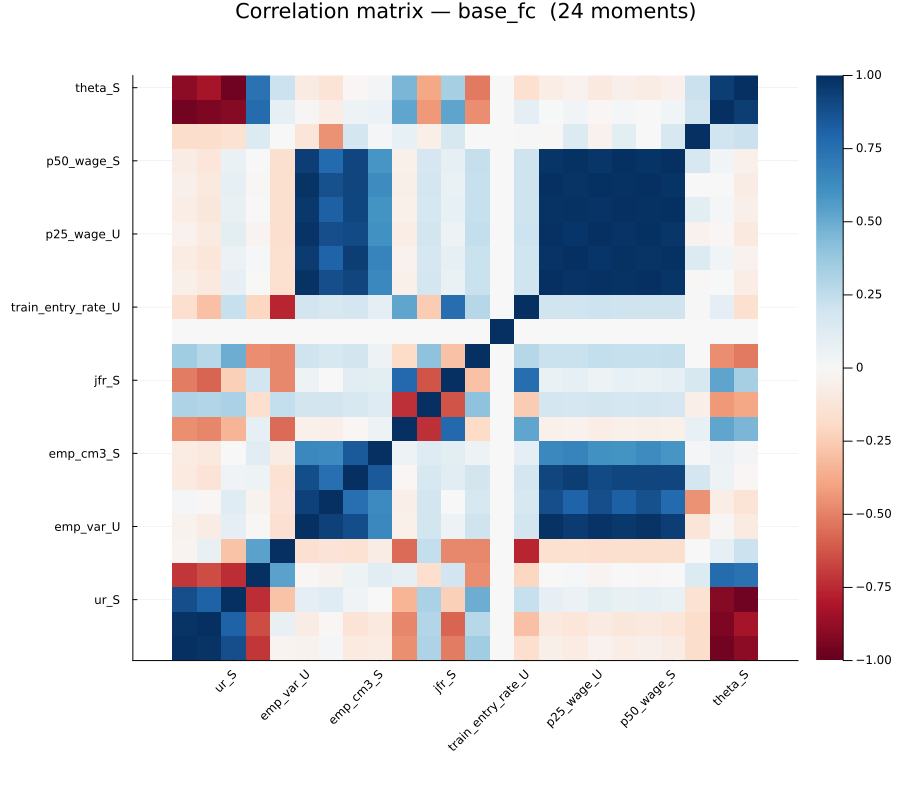


Top 15 correlated moment pairs (|r|):
moment A              moment B                |corr|
--------------------------------------------------
  mean_wage_U           p50_wage_U            0.9994
  p25_wage_S            p50_wage_S            0.9978
  p25_wage_U            p50_wage_U            0.9978
  mean_wage_U           p25_wage_U            0.9959
  mean_wage_S           p25_wage_S            0.9950
  mean_wage_S           p50_wage_S            0.9946
  p25_wage_S            p50_wage_U            0.9934
  emp_var_U             mean_wage_U           0.9917
  mean_wage_U           p25_wage_S            0.9916
  mean_wage_S           p50_wage_U            0.9890
  ur_total              ur_U                  0.9888
  emp_var_U             p50_wage_U            0.9883
  mean_wage_U           mean_wage_S           0.9877
  p25_wage_U            p25_wage_S            0.9875
  emp_var_U             p25_wage_U            0.9874

Condition number κ(Σ) for base_fc: 4.57e+19


In [28]:
# ── Correlation matrix heatmap ───────────────────────────────────────────────
using Plots, StatsPlots

wname_plot = :base_fc   # change to any window
Sigma_plot = all_sigma[wname_plot]
names_plot = string.(MOMENT_NAMES)

d     = sqrt.(abs.(diag(Sigma_plot)))
D_inv = Diagonal(1.0 ./ max.(d, 1e-14))
Corr  = D_inv * Sigma_plot * D_inv
Corr  = clamp.(Corr, -1.0, 1.0)

p1 = heatmap(
    names_plot, names_plot, Corr;
    aspect_ratio = 1,
    color        = :RdBu,
    clims        = (-1, 1),
    colorbar     = true,
    title        = "Correlation matrix — $(wname_plot)  ($(length(names_plot)) moments)",
    xrotation    = 45,
    size         = (900, 800),
)
display(p1)

K_p = length(names_plot)
pairs_corr = [(abs(Corr[i,j]), names_plot[i], names_plot[j])
              for i in 1:K_p for j in i+1:K_p]
sort!(pairs_corr, rev=true)

println("\nTop 15 correlated moment pairs (|r|):")
println(rpad("moment A", 22), rpad("moment B", 22), "  |corr|")
println("-"^50)
for (r, a, b) in pairs_corr[1:min(15, end)]
    @printf("  %-20s  %-20s  %.4f\n", a, b, r)
end

@printf("\nCondition number κ(Σ) for %s: %.2e\n", wname_plot, cond(Sigma_plot))


---
## Stage 9 — Validation and Diagnostics

Spot-check moments against published benchmarks. Cross-window comparison.
Tightness level check. EE rate validation. Training share check.

In [29]:
function run_validation(all_moments, all_sigma)
    @info "Stage 9: Validation diagnostics..."

    println("\n" * "="^80)
    println("VALIDATION REPORT")
    println("="^80)

    # ── 1. Moment values across windows ───────────────────────────
    println("\n── 1. Moments across windows ──")
    wide = DataFrame(moment = [string(m) for m in MOMENT_NAMES])
    for wname in WINDOWS_ORDER
        haskey(all_moments, wname) || continue
        mdf = all_moments[wname]
        wide[!, string(wname)] = mdf.value
    end
    display(wide)

    # ── 2. Sanity checks with published benchmarks ────────────────
    println("\n── 2. Benchmark comparisons ──")
    benchmarks = Dict(
        :skilled_share => (name="Skilled share (BA+)", lo=0.20, hi=0.50),
        :training_share => (name="Training share (NILF ∩ train / pop)", lo=0.005, hi=0.05),
        :theta_U => (name="Unskilled tightness V/U", lo=0.1, hi=5.0),
        :theta_S => (name="Skilled tightness V/U", lo=0.1, hi=10.0),
        :jfr_U => (name="Unskilled JF rate (monthly)", lo=0.10, hi=0.50),
        :sep_rate_U => (name="Unskilled EU sep rate (monthly)", lo=0.005, hi=0.05),
        :ee_rate_S => (name="Skilled EE rate (monthly)", lo=0.005, hi=0.05),
        :wage_premium => (name="Log skill premium", lo=0.20, hi=0.80),
        :p25_wage_U => (name="p25 wage unskilled (norm.)", lo=0.40, hi=0.90),
        :p25_wage_S => (name="p25 wage skilled (norm.)", lo=0.70, hi=1.20),
        :train_entry_rate_U => (name="Train-entry rate (unskilled-unemp)", lo=0.0005, hi=0.05),
    )

    n_flags = 0
    for (mname, bm) in benchmarks
        for wname in WINDOWS_ORDER
            haskey(all_moments, wname) || continue
            mdf = all_moments[wname]
            row = filter(r -> r.moment == string(mname), mdf)
            isempty(row) && continue
            val = row.value[1]
            !isfinite(val) && continue
            flag = val < bm.lo || val > bm.hi ? "⚠ OUT OF RANGE" : "✓"
            if flag != "✓"
                @printf("  %s  %-32s %12s = %8.4f  (expected %.4f–%.4f)\n",
                        flag, bm.name, wname, val, bm.lo, bm.hi)
                n_flags += 1
            end
        end
    end
    println("  Flagged: $n_flags values outside expected ranges")

    # ── 3. Cross-window direction checks ──────────────────────────
    println("\n── 3. Cross-window direction checks ──")
    expected_directions = [
        (:ur_U,   :base_fc,    :crisis_fc,    +1, "UR_U should rise in FC"),
        (:ur_U,   :base_covid, :crisis_covid, +1, "UR_U should rise in COVID"),
        (:jfr_U,  :base_fc,    :crisis_fc,    -1, "JFR_U should fall in FC"),
        (:theta_U,:base_fc,    :crisis_fc,    -1, "θ_U should fall in FC"),
        (:theta_U,:base_covid, :crisis_covid, -1, "θ_U should fall in COVID"),
    ]
    for (mname, w1, w2, expected_sign, desc) in expected_directions
        haskey(all_moments, w1) && haskey(all_moments, w2) || continue
        v1 = filter(r -> r.moment == string(mname), all_moments[w1]).value[1]
        v2 = filter(r -> r.moment == string(mname), all_moments[w2]).value[1]
        (!isfinite(v1) || !isfinite(v2)) && continue
        actual_sign = sign(v2 - v1)
        flag = actual_sign == expected_sign ? "✓" : "⚠ UNEXPECTED"
        @printf("  %s  %s: %.4f → %.4f (Δ=%.4f)\n", flag, desc, v1, v2, v2-v1)
    end

    # ── 4. train_entry_rate_U cross-window comparison ─────────────
    # Primary cross-check for whether a COVID-era training decline
    # is a structural shift in the decision rule (c) or a
    # compositional change in the unskilled-unemployed pool.
    println("\n── 4. train_entry_rate_U across windows ──")
    te = Dict{Symbol, Float64}()
    for wname in WINDOWS_ORDER
        haskey(all_moments, wname) || continue
        mdf = all_moments[wname]
        row = filter(r -> r.moment == "train_entry_rate_U", mdf)
        isempty(row) && continue
        te[wname] = row.value[1]
        @printf("  %-14s  train_entry_rate_U = %.6f\n", wname, te[wname])
    end
    for (base, crisis) in ((:base_fc, :crisis_fc), (:base_covid, :crisis_covid))
        if haskey(te, base) && haskey(te, crisis) && te[base] > 0
            pct = 100 * (te[crisis] / te[base] - 1)
            @printf("    Δ%% %s → %s: %+.2f%%\n", base, crisis, pct)
        end
    end

    # ── 5. Stationary-identity gap by window ──────────────────────
    # Model identity (d ≡ 0 in stationary equilibrium, strict
    # training_share convention):
    #     skilled_share * (1 - training_share)
    #   = (φ/ν) * training_share
    # A small residual is informative; a large residual flags
    # non-stationarity in the window.
    println("\n── 5. Stationary-identity gap (skilled_share / training_share / φ / ν) ──")

    phi_cal = let p = joinpath(DERIVED_DIR, "phi_calibration.csv")
        isfile(p) ? CSV.read(p, DataFrame).phi[1] : NaN
    end
    nu_tbl = let p = joinpath(DERIVED_DIR, "nu_estimation.csv")
        isfile(p) ? CSV.read(p, DataFrame) : nothing
    end
    nu_lookup = Dict{Symbol, Float64}()
    if nu_tbl !== nothing
        for r in eachrow(nu_tbl)
            nu_lookup[Symbol(r.window)] = r.nu
        end
    end
    # Each crisis pair shares the ν of its baseline
    nu_for = Dict(
        :base_fc      => get(nu_lookup, :base_fc, NaN),
        :crisis_fc    => get(nu_lookup, :base_fc, NaN),
        :base_covid   => get(nu_lookup, :base_covid, NaN),
        :crisis_covid => get(nu_lookup, :base_covid, NaN),
    )

    @printf("    φ = %.6f (pooled)\n", phi_cal)
    for wname in WINDOWS_ORDER
        haskey(all_moments, wname) || continue
        mdf = all_moments[wname]
        ss  = filter(r -> r.moment == "skilled_share", mdf).value[1]
        ts  = filter(r -> r.moment == "training_share", mdf).value[1]
        nu  = nu_for[wname]
        if isfinite(ss) && isfinite(ts) && isfinite(phi_cal) && isfinite(nu) && ts > 0
            lhs = ss * (1 - ts)
            rhs = (phi_cal / nu) * ts
            gap = lhs / rhs - 1
            @printf("    %-14s  ν = %.6f  gap = %+.3f  (LHS/RHS - 1)\n",
                    wname, nu, gap)
        end
    end

    # ── 6. Σ̂ diagnostics ─────────────────────────────────────────
    println("\n── 6. Σ̂ condition numbers ──")
    for wname in WINDOWS_ORDER
        haskey(all_sigma, wname) || continue
        Sig = all_sigma[wname]
        d = diag(Sig)
        n_zero = count(d .<= 0)
        cn = cond(Sig)
        @printf("  %s: κ = %.2e, zero-diagonal = %d\n", wname, cn, n_zero)
    end

    println("\n" * "="^80)
    println("END VALIDATION REPORT")
    println("="^80)
end

run_validation(all_moments, all_sigma)


Row,moment,base_fc,crisis_fc,base_covid,crisis_covid
,String,Float64,Float64,Float64,Float64
1,ur_total,0.0522866,0.083091,0.0444482,0.0597889
2,ur_U,0.0636225,0.102668,0.0562962,0.0757019
3,ur_S,0.0260133,0.0417203,0.0246717,0.0370511
4,skilled_share,0.301639,0.320734,0.376597,0.410952
5,training_share,0.0195862,0.0221747,0.0298713,0.0286289
6,emp_var_U,0.254256,0.253269,0.285969,0.284078
7,emp_cm3_U,0.170862,0.17574,0.262403,0.30723
8,emp_var_S,0.393375,0.406544,0.449833,0.430115
9,emp_cm3_S,0.233732,0.264206,0.351389,0.369498



VALIDATION REPORT

── 1. Moments across windows ──


┌ Info: Stage 9: Validation diagnostics...
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y200sZmlsZQ==.jl:2



── 2. Benchmark comparisons ──
  Flagged: 0 values outside expected ranges

── 3. Cross-window direction checks ──
  ✓  UR_U should rise in FC: 0.0636 → 0.1027 (Δ=0.0390)
  ✓  UR_U should rise in COVID: 0.0563 → 0.0757 (Δ=0.0194)
  ✓  JFR_U should fall in FC: 0.2610 → 0.1899 (Δ=-0.0711)
  ✓  θ_U should fall in FC: 0.9183 → 0.4498 (Δ=-0.4686)
  ⚠ UNEXPECTED  θ_U should fall in COVID: 1.5635 → 2.0526 (Δ=0.4890)

── 4. train_entry_rate_U across windows ──
  base_fc         train_entry_rate_U = 0.019025
  crisis_fc       train_entry_rate_U = 0.017980
  base_covid      train_entry_rate_U = 0.030468
  crisis_covid    train_entry_rate_U = 0.025244
    Δ% base_fc → crisis_fc: -5.49%
    Δ% base_covid → crisis_covid: -17.15%

── 5. Stationary-identity gap (skilled_share / training_share / φ / ν) ──
    φ = 0.022221 (pooled)
    base_fc         ν = 0.003230  gap = +1.195  (LHS/RHS - 1)
    crisis_fc       ν = 0.003230  gap = +1.056  (LHS/RHS - 1)
    base_covid      ν = 0.003357  gap = +0.848  

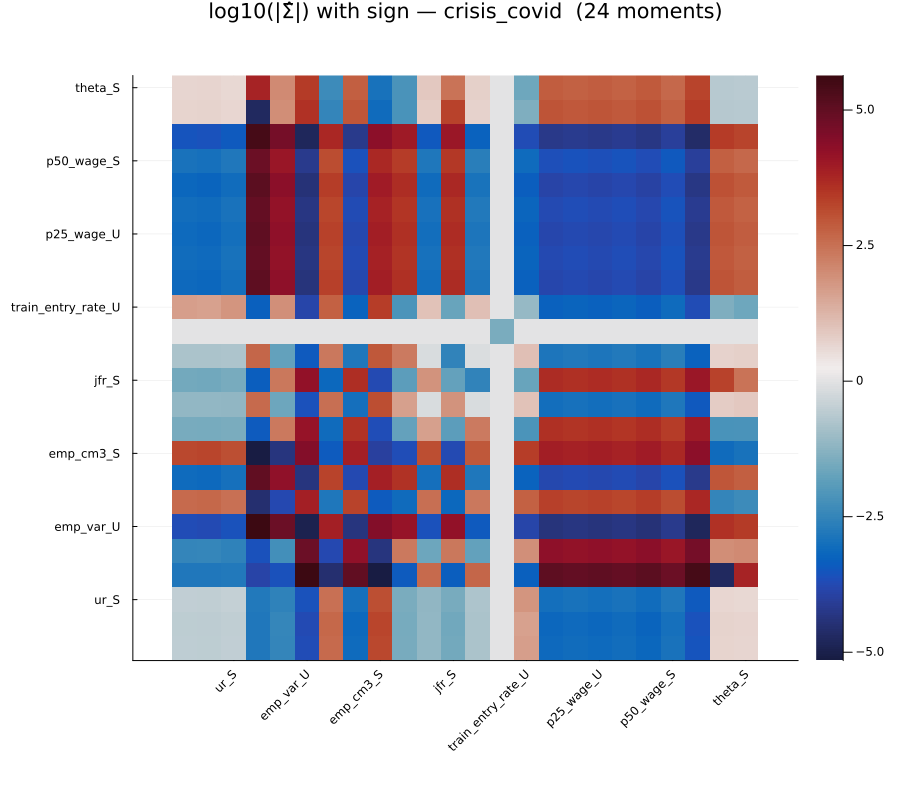

In [30]:
using DataFrames, CSV, LinearAlgebra
using Plots
using StatsPlots

wname = first(keys(all_sigma))
Sigma = all_sigma[wname]
eps0  = 1e-20
Sigma_log = sign.(Sigma) .* log10.(abs.(Sigma) .+ eps0)

p = heatmap(
    string.(MOMENT_NAMES), string.(MOMENT_NAMES), Sigma_log;
    aspect_ratio = 1,
    cmap         = :balance,
    colorbar     = true,
    title        = "log10(|Σ̂|) with sign — $(wname)  ($(length(MOMENT_NAMES)) moments)",
    xrotation    = 45,
    yrotation    = 0,
    size         = (900, 800)
)
display(p)


In [31]:
using DataFrames, Statistics

moment_vars = DataFrame(
    moment   = String[],
    window   = Symbol[],
    variance = Float64[]
)

for (wname, Sigma) in all_sigma
    for (i, m) in enumerate(MOMENT_NAMES)
        push!(moment_vars, (String(m), wname, Sigma[i, i]))
    end
end

var_table = combine(
    groupby(moment_vars, :moment),
    :variance => mean    => :mean_variance,
    :variance => minimum => :min_variance,
    :variance => maximum => :max_variance,
    nrow => :n_windows
)

sort!(var_table, :mean_variance, rev=true)
var_table.rank = 1:nrow(var_table)

display(var_table)


Row,moment,mean_variance,min_variance,max_variance,n_windows,rank
,String,Float64,Float64,Float64,Int64,Int64
1,sep_rate_S,0.201951,0.0155171,0.740072,4,1
2,sep_rate_U,0.178537,0.00402143,0.682153,4,2
3,theta_S,0.153895,0.0227743,0.289952,4,3
4,theta_U,0.126889,0.0441704,0.214155,4,4
5,ur_S,0.109703,0.0117839,0.341533,4,5
6,ur_total,0.0895811,0.0119034,0.284171,4,6
7,ur_U,0.0855581,0.00993838,0.269549,4,7
8,train_entry_rate_U,0.0844217,0.0483918,0.109922,4,8
9,jfr_S,0.0247358,0.0162979,0.0405939,4,9


---
## Pipeline Summary

List all derived files produced by the pipeline.

In [32]:
println("Derived files in: $DERIVED_DIR")
for f in sort(readdir(DERIVED_DIR))
    sz = filesize(joinpath(DERIVED_DIR, f))
    @printf("  %-40s  %s\n", f, Base.format_bytes(sz))
end

println("\nKey outputs:")
println("  • windows.json                 — single source of truth for WINDOWS (4 entries)")
println("  • moments_{window}.csv         — 24 moments per window")
println("  • sigma_{window}.csv           — 24×24 variance-covariance matrix (full)")
println("  • moment_scales_{window}.csv   — scale factors used for IF normalisation")
println("  • j2j_ee_rates.csv             — J2J E4-only EE rates by window")
println("  • nu_estimation.csv            — ν on base_fc AND base_covid (life-table)")
println("  • phi_calibration.csv          — training completion rate φ (pooled)")


Derived files in: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived
  W_base_covid.csv                          3.239 KiB
  W_base_fc.csv                             3.233 KiB
  W_crisis_covid.csv                        2.381 KiB
  W_crisis_fc.csv                           2.352 KiB
  W_reduced_base_covid.csv                  2.066 KiB
  W_reduced_base_fc.csv                     2.066 KiB
  W_reduced_crisis_covid.csv                2.063 KiB
  W_reduced_crisis_fc.csv                   2.063 KiB
  cps_asec_clean.arrow                      16.686 MiB
  cps_basic_clean.arrow                     2.956 GiB
  cps_vs_nsc_enrollment.csv                 486 bytes
  economy_skill_shares.arrow                1.018 KiB
  enrollment_rate_by_age.csv                305 bytes
  industry_skill_shares.arrow               3.713 KiB
  j2j_ee_rates.csv                          165 bytes
  jolts_clean.arrow                         14.096 KiB
  moment_scale